In [5]:
import os
from pathlib import Path

os.chdir("/mnt/data/ProjetMeteo/Analyse_Meteo")
Path.cwd()

PosixPath('/mnt/data/ProjetMeteo/Analyse_Meteo')

The EMD algorithm extracted 7 IMFs and 1 Residual.


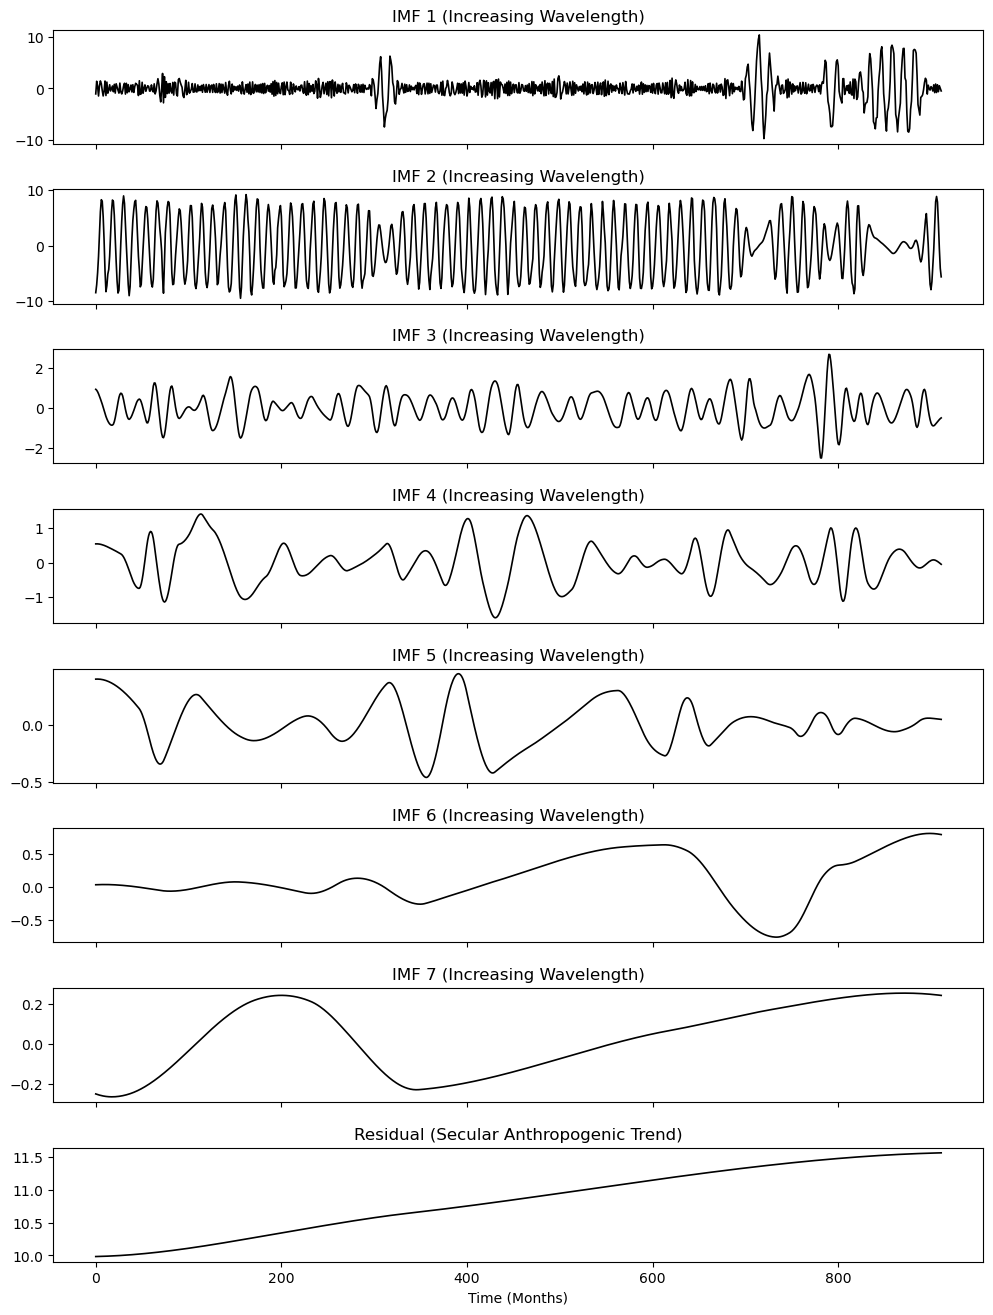

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from PyEMD import EMD
from pathlib import Path
import os

raw_french_temp_array = np.load("month_mean_serie.npy")
cycle_array = np.load("cycle_serie.npy")

# ==============================================================================
# 1. AUTONOMOUS SIGNAL FRACTURING
# ==============================================================================

# We instantiate the EMD engine and run the decomposition
emd_engine = EMD(spline_kind='akima',extrema_detection='parabol',std_thr=0.01)
imfs = emd_engine.emd(raw_french_temp_array)

# The output 'imfs' is a 2D numpy array where each row is an Intrinsic Mode Function.
# The final row is the residual (trend).
num_imfs = imfs.shape[0]
print(f"The EMD algorithm extracted {num_imfs - 1} IMFs and 1 Residual.")

# ==============================================================================
# 2. VISUAL DISSECTION
# ==============================================================================
# Build a stacked plot architecture
fig, axes = plt.subplots(num_imfs, 1, figsize=(12, 2 * num_imfs), sharex=True)
plt.subplots_adjust(hspace=0.4)

time_axis = np.arange(len(raw_french_temp_array))

for i in range(num_imfs):
    ax = axes[i]
    ax.plot(time_axis, imfs[i], color='black', linewidth=1.2)
    
    if i == num_imfs - 1:
        ax.set_title("Residual (Secular Anthropogenic Trend)")
    else:
        ax.set_title(f"IMF {i+1} (Increasing Wavelength)")
        
plt.xlabel("Time (Months)")
plt.show()

In [72]:
np.std(cycle_array)

np.float64(0.9994516040168877)

Extraction complete. Isolated 6 clean IMFs and 1 Residual.


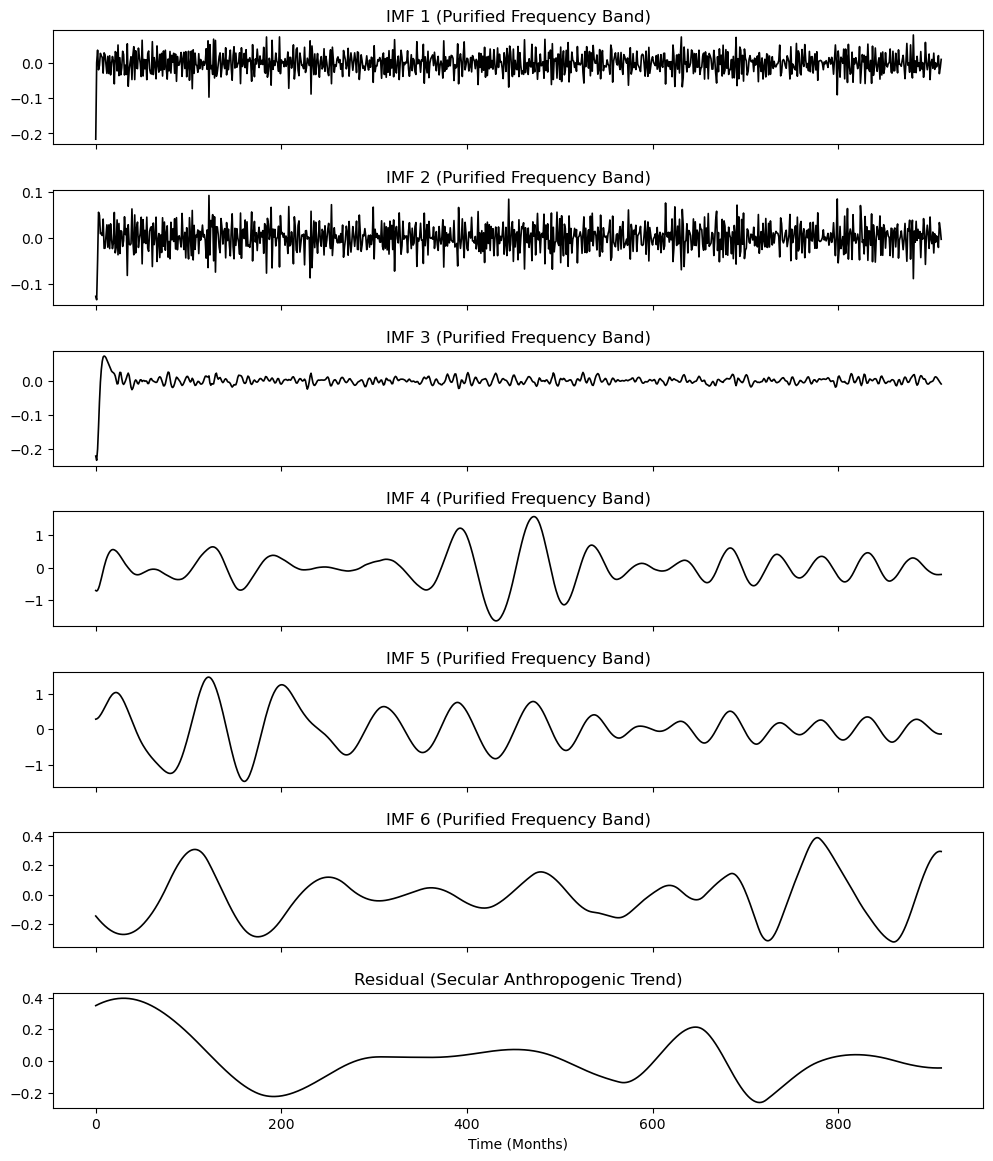

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from PyEMD import EEMD, CEEMDAN

# ==============================================================================
# 1. CONFIGURE THE ENSEMBLE ENGINE
# ==============================================================================
# Instantiate the EEMD engine. 
# We configure the EMD core within it to use strict envelope physics.
strict_core = EMD(spline_kind='akima',extrema_detection='parabol',std_thr=0.01
)

eemd_engine_raw = CEEMDAN(
    trials=100,     # Standard Deviation of the injected noise (relative to signal)
    parallel=True, 
    ext_EMD=strict_core,
    epsilon=0.05*np.std(raw_french_temp_array)
)

eemd_engine_cycle = CEEMDAN(
    trials=100,     # Standard Deviation of the injected noise (relative to signal)
    parallel=True, 
    ext_EMD=strict_core,
    epsilon=0.05
)


# Execute the ensemble decomposition on your raw numpy array
# Note: EEMD is highly computationally expensive. 100 trials means it runs EMD 100 times.
#imfs = eemd_engine_raw.ceemdan(raw_french_temp_array, max_imf=6)
imfs = eemd_engine_raw.ceemdan(cycle_array, max_imf=6)


num_imfs = imfs.shape[0]
print(f"Extraction complete. Isolated {num_imfs - 1} clean IMFs and 1 Residual.")

# ==============================================================================
# 3. VISUALIZE THE PURIFIED MODES
# ==============================================================================
fig, axes = plt.subplots(num_imfs, 1, figsize=(12, 2 * num_imfs), sharex=True)
plt.subplots_adjust(hspace=0.4)

time_axis = np.arange(len(raw_french_temp_array))

for i in range(num_imfs):
    ax = axes[i]
    ax.plot(time_axis, imfs[i], color='black', linewidth=1.2)
    
    if i == num_imfs - 1:
        ax.set_title("Residual (Secular Anthropogenic Trend)")
    else:
        ax.set_title(f"IMF {i+1} (Purified Frequency Band)")
        
plt.xlabel("Time (Months)")
plt.show()

In [7]:
import pandas as pd

# ==============================================================================
# 1. PARSE THE RAW TEXT FILES
# ==============================================================================
# sep='\s+' instructs pandas to treat any amount of consecutive whitespace as a single delimiter.
# na_values=[-99.9, -99.90] captures the standard NOAA missing data flags.

# Load North Atlantic Oscillation
df_nao = pd.read_csv("demo_france/NAO.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)

# Load East Atlantic Pattern
df_ea = pd.read_csv("demo_france/EA.txt", sep='\s+', na_values=[-99.9, -99.90])

# ==============================================================================
# 2. STANDARDIZE THE COLUMNS
# ==============================================================================
# Ensure the columns are strictly named for accurate merging
df_nao.columns = ['Year', 'Month', 'NAO']
df_ea.columns = ['Year', 'Month', 'EA']

# ==============================================================================
# 3. MERGE INTO THE MASTER CLIMATE MATRIX
# ==============================================================================
# We perform an 'inner' merge on the Year and Month columns. 
# This strictly enforces temporal alignment. If a month is missing in one file, 
# it drops the row to prevent out-of-phase signal corruption.
df_climate = pd.merge(df_nao, df_ea, on=['Year', 'Month'], how='inner')

# ==============================================================================
# 4. BUILD THE CHRONOLOGICAL TIME INDEX
# ==============================================================================
# Convert the discrete Year and Month integer columns into a continuous DateTime object.
# We assign '01' as the day for every month to satisfy the DateTime requirement.
df_climate['Date'] = pd.to_datetime(
    df_climate['Year'].astype(str) + '-' + df_climate['Month'].astype(str) + '-01'
)

# Set the continuous Date vector as the strict mathematical index of the DataFrame
df_climate.set_index('Date', inplace=True)

# Drop the now redundant discrete temporal columns
df_climate.drop(columns=['Year', 'Month'], inplace=True)

# ==============================================================================
# 5. VERIFY MATRIX INTEGRITY
# ==============================================================================
print(df_climate.info())
print("\nFirst 5 rows:")
print(df_climate.head())

<class 'pandas.DataFrame'>
DatetimeIndex: 915 entries, 1950-01-01 to 2026-03-01
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NAO     915 non-null    float64
 1   EA      915 non-null    float64
dtypes: float64(2)
memory usage: 21.4 KB
None

First 5 rows:
             NAO    EA
Date                  
1950-01-01  0.92 -2.71
1950-02-01  0.40  0.66
1950-03-01 -0.36  0.82
1950-04-01  0.73  0.28
1950-05-01 -0.59 -0.51


<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_172174/45244839.py:10: SyntaxWarning: invalid escape sequence '\s'
  df_nao = pd.read_csv("demo_france/NAO.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)
/tmp/ipykernel_172174/45244839.py:13: SyntaxWarning: invalid escape sequence '\s'
  df_ea = pd.read_csv("demo_france/EA.txt", sep='\s+', na_values=[-99.9, -99.90])


In [25]:
df_climate.NAO

Date
1950-01-01    0.9200
1950-02-01    0.4000
1950-03-01   -0.3600
1950-04-01    0.7300
1950-05-01   -0.5900
               ...  
2025-11-01   -0.7847
2025-12-01   -0.6461
2026-01-01   -0.3602
2026-02-01    0.6807
2026-03-01    2.6858
Name: NAO, Length: 915, dtype: float64

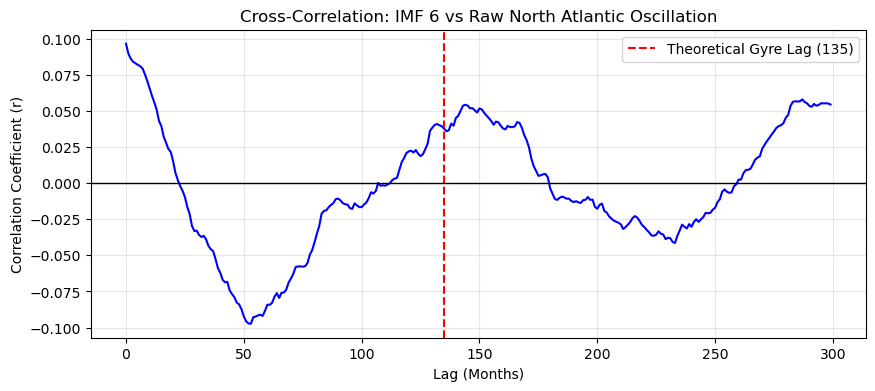

In [81]:
import statsmodels.api as sm

# Assume 'imfs' is your 2D numpy array from the EEMD output
# Assume 'df_climate' is your dataframe containing the raw 'NAO' and 'EA' columns

# ==============================================================================
# 1. VERIFYING THE OCEANIC MEMORY (IMF 6 vs NAO)
# ==============================================================================
# Extract IMF 6 (Adjust index depending on your specific EEMD output)
imf_ocean = imfs[5] 
raw_nao = df_climate['NAO'].values

# Calculate Cross-Correlation up to 200 months of lag
# Note: ccf() computes correlation where the second array lags the first.
ccf_ocean = sm.tsa.stattools.ccf(imf_ocean, raw_nao, adjusted=False)[:300]

plt.figure(figsize=(10, 4))
# Plot the CCF array
plt.plot(np.arange(300), ccf_ocean, color='blue', linewidth=1.5)
plt.axvline(x=135, color='red', linestyle='--', label='Theoretical Gyre Lag (135)')
plt.axhline(y=0, color='black', linewidth=1)
plt.title("Cross-Correlation: IMF 6 vs Raw North Atlantic Oscillation")
plt.xlabel("Lag (Months)")
plt.ylabel("Correlation Coefficient (r)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

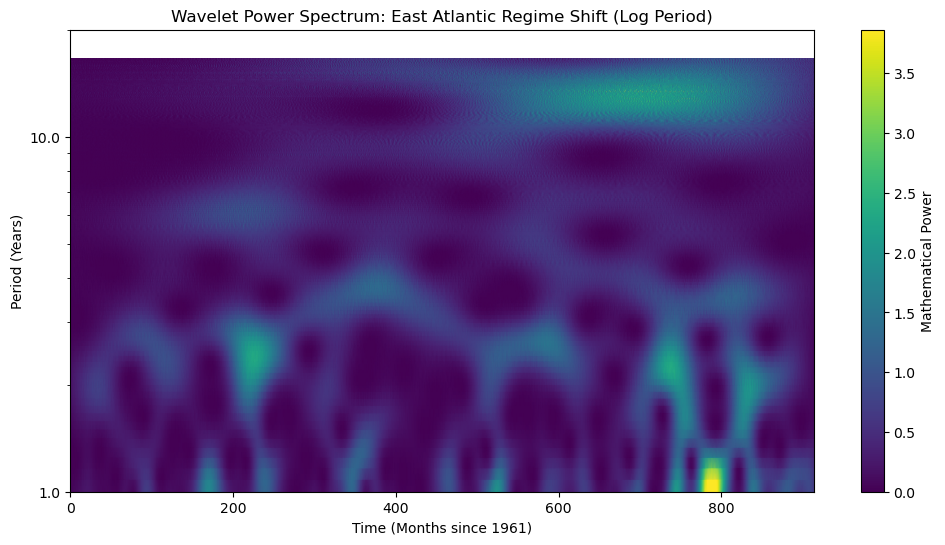

In [8]:
import numpy as np
import pywt
import matplotlib.pyplot as plt

# ==============================================================================
# 1. APPLY THE MORLET WAVELET TRANSFORM
# ==============================================================================
# Assume df_ortho is a pandas DataFrame and EA_Lag0 is your standardized array
signal = df_climate['NAO'].values
time_axis = np.arange(len(signal))

# We define the scales (which correlate inversely with frequency/period)
# We calculate up to 200 scales to capture high and low frequencies
scales = np.arange(1, 200)

# Execute the Continuous Wavelet Transform using a Complex Morlet wavelet
# cmor1.5-1.0 indicates a bandwidth of 1.5 and center frequency of 1.0
coefficients, frequencies = pywt.cwt(signal, scales, 'cmor1.5-1.0')

# ==============================================================================
# 2. RENDER THE 3D THERMODYNAMIC HEATMAP
# ==============================================================================
# Calculate the absolute mathematical power of the complex matrix
periods_months = 1 / frequencies

# 2. Convert periods to Years for physical interpretation
periods_years = periods_months / 12

# Calculate the mathematical power
wave_power = np.abs(coefficients)**2

plt.figure(figsize=(12, 6))

# Render using pcolormesh. 
# We use periods_years for the Y-axis.
plt.pcolormesh(time_axis, periods_years, wave_power, shading='gouraud', cmap='viridis')

plt.colorbar(label='Mathematical Power')

# Set the Y-axis to logarithmic to prevent low-frequency squashing
plt.yscale('log')

# Limit the Y-axis to physically relevant climate domains (e.g., 1 year to 20 years)
plt.ylim(1, 20)

# Format the Y-axis ticks so they display readable numbers instead of scientific notation
from matplotlib.ticker import ScalarFormatter
plt.gca().yaxis.set_major_formatter(ScalarFormatter())

plt.ylabel('Period (Years)')
plt.xlabel('Time (Months since 1961)')
plt.title('Wavelet Power Spectrum: East Atlantic Regime Shift (Log Period)')

# Highlight the hottest structural anomalies
plt.clim(0, np.max(wave_power) * 0.8) 
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

def analyze_fft(time_series, sampling_interval=1.0, time_unit='Months'):
    """
    Computes the Fast Fourier Transform (FFT) of a given time series.
    
    Parameters:
    time_series (array-like): The discrete time series data (e.g., IMF 5).
    sampling_interval (float): The time interval between samples. Default is 1.0.
    time_unit (str): The unit of time for plotting purposes.
    
    Returns:
    frequencies (ndarray): The positive frequencies.
    power_spectrum (ndarray): The normalized power spectrum.
    """
    N = len(time_series)
    
    # Compute the 1D discrete Fourier Transform
    # Subtracting the mean removes the DC component (0 Hz)
    yf = fft(time_series - np.mean(time_series))
    
    # Compute the corresponding frequencies
    # sampling_interval = 1 means 1 sample per time_unit
    xf = fftfreq(N, d=sampling_interval)
    
    # Extract only the positive half of the spectrum (Nyquist limit)
    positive_freq_indices = np.where(xf > 0)
    frequencies = xf[positive_freq_indices]
    
    # Calculate the normalized amplitude/power spectrum
    # yf returns complex numbers; np.abs gets the magnitude
    # Multiply by 2.0/N to normalize the amplitude
    amplitudes = (2.0 / N) * np.abs(yf[positive_freq_indices])
    power_spectrum = amplitudes ** 2
    
    # Identify the dominant frequency and its period
    peak_idx = np.argmax(power_spectrum)
    dominant_freq = frequencies[peak_idx]
    dominant_period = 1.0 / dominant_freq if dominant_freq > 0 else np.inf
    
    print(f"Dominant Frequency: {dominant_freq:.5f} cycles/{time_unit}")
    print(f"Dominant Period: {dominant_period:.2f} {time_unit}")
    
    # Plotting the Power Spectrum
    plt.figure(figsize=(10, 5))
    plt.plot(frequencies, power_spectrum, color='black', linewidth=1.5)
    plt.title('Power Spectral Density via FFT')
    plt.xlabel(f'Frequency (cycles/{time_unit})')
    plt.ylabel('Power')
    
    # Optional: Plot against period on a secondary X-axis for interpretation
    plt.axvline(x=dominant_freq, color='red', linestyle='--', label=f'Peak: {dominant_period:.1f} {time_unit}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return frequencies, power_spectrum

# --- Example Execution ---
# Assuming 'imf5_data' is a 1D numpy array containing the extracted IMF 5 values
# sampling_interval=1 (1 measurement per month based on the provided axes)
# frequencies, power = analyze_fft(imf5_data, sampling_interval=1.0, time_unit='Months')

In [9]:
df_climate = df_climate[:912]
df_climate['raw'] = raw_french_temp_array
#df_climate['cycle'] = cycle_array

In [10]:
import pandas as pd
import numpy as np

# Assuming you have your raw 1D array of monthly data loaded
# Example: raw_data_array = raw_french_temp_array

def build_climate_dataframe(raw_data_array):
    """
    Constructs the exact DataFrame architecture required for the 
    Zero-Intercept GLM seasonal and secular trend extraction.
    """
    # 1. Initialize the DataFrame with the target variable 'Y'
    df = pd.DataFrame({'Y': raw_data_array})
    
    N = len(df)
    
    # 2. Create the linear time vector 't1' (1, 2, 3, ..., N)
    # This represents the strictly linear component of the secular trend.
    df['t1'] = np.arange(1, N + 1)
    
    # 3. Create the quadratic time vector 't2' 
    # This captures non-linear acceleration in the secular trend (e.g., anthropogenic warming).
    df['t2'] = df['t1'] ** 2
    
    # 4. Create the deterministic 'Month' categorical variable (1 through 12, repeating)
    # np.tile replicates the 1-12 sequence. We calculate how many full years are needed,
    # generate the sequence, and then slice [:N] to ensure it exactly matches the data length.
    full_years_needed = int(np.ceil(N / 12))
    repeating_months = np.tile(np.arange(1, 13), full_years_needed)
    
    df['Month'] = repeating_months[:N]
    
    return df

# ==============================================================================
# EXECUTION
# ==============================================================================
# Build the master DataFrame
df_months = build_climate_dataframe(raw_french_temp_array)

# Verify the mathematical structure
print(df_months.head(15))

            Y  t1   t2  Month
0    2.148903   1    1      1
1    5.969903   2    4      2
2    7.083308   3    9      3
3    8.031222   4   16      4
4   13.992700   5   25      5
5   18.719281   6   36      6
6   20.218401   7   49      7
7   18.474729   8   64      8
8   14.517998   9   81      9
9   10.989987  10  100     10
10   7.263499  11  121     11
11   0.573856  12  144     12
12   4.137536  13  169      1
13   3.931110  14  196      2
14   5.324305  15  225      3


In [9]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.signal import butter, filtfilt

# Assume df_months is a Pandas DataFrame containing 'Y', 't1', 't2'
# If you need to generate the repeating month sequence:
#df_months['Month'] = np.tile(np.arange(1, 13), int(np.ceil(len(df_months)/12)))[:len(df_months)]

# ==============================================================================
# STEP 1 & 2: GLM FIT AND NATIVE PRE-WHITENING
# ==============================================================================
# In statsmodels, C(Month) automatically generates the 12 seasonal dummies.
# The "- 1" strictly enforces the Zero-Intercept architecture you used in Julia.
poly_seasonal_model = smf.ols('Y ~ t1 + t2 + C(Month) - 1', data=df_months).fit()

# Python Advantage: The pre-whitened signal (Y - trend - seasonality) 
# is natively stored in the model's residual array. You do not need to 
# manually reconstruct and subtract the vectors.
glm_residuals = poly_seasonal_model.resid

# Optional: If you still need the global baseline for other analyses
coefs = poly_seasonal_model.params
monthly_intercepts = coefs[[col for col in coefs.index if 'C(Month)' in col]]
true_global_intercept = np.mean(monthly_intercepts)

# ==============================================================================
# STEP 3: DIGITAL SIGNAL PROCESSING (THE STOCHASTIC CYCLE)
# ==============================================================================
# Note on your Julia code: Your comment mentioned 120 to 720 months, 
# but the code used 1/84 and 1/24 (2 to 7 years). 
# I am using the 24 to 84-month frequencies from your code.

# Define frequencies (cycles per month). Sampling frequency (fs) = 1 month.
lowcut = 1.0 / 84.0
highcut = 1.0 / 24.0

# Design the 4th-order Butterworth Band-Pass filter
b, a = butter(4, [lowcut, highcut], btype='bandpass', fs=1.0)

# Apply zero-phase filtering (filtfilt) to the GLM residuals
extracted_oceanic_cycle = filtfilt(b, a, glm_residuals)
filtered_empirical_nao = filtfilt(b, a, df_climate['NAO'])
filtered_empirical_ea = filtfilt(b, a, df_climate['EA'])

In [11]:
df_climate['filt_nao'] = filtered_empirical_nao
df_climate['filt_ea'] = filtered_empirical_ea
df_climate['filt_cycle'] = extracted_oceanic_cycle

In [12]:
import pandas as pd
import numpy as np

# Assuming 'nao_raw' is your 1D array or list of the 900-month NAO index
# Assuming 'time_months' is your corresponding time array
df = df_climate

# Create the lagged column
# A positive shift moves the past values forward to present indices
lag_value = 135
df['NAO_Lag_135'] = df['filt_nao'].shift(lag_value)

# For subsequent statistical functions (like correlation), you must remove the NaNs
df_clean = df.dropna()

print(df_clean.head())

             NAO    EA        raw  filt_nao   filt_ea  filt_cycle  NAO_Lag_135
Date                                                                          
1961-04-01 -1.55  1.52  11.888179  0.222211  0.301486    0.577466    -0.042300
1961-05-01 -0.36 -0.72  12.757525  0.260876  0.327088    0.673994    -0.211130
1961-06-01  0.86  1.83  16.904007  0.289866  0.337185    0.748170    -0.372082
1961-07-01 -0.39 -0.74  18.033236  0.307115  0.330455    0.794920    -0.520158
1961-08-01  0.90 -0.16  18.077735  0.311229  0.306292    0.810418    -0.650821


  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:00


 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:00
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
/tmp/ipykernel_117951/1529489483.py:27: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(master_gam.summary())


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     15.2367
Link Function:                     IdentityLink Log Likelihood:                                  -364.5678
Number of Samples:                          777 AIC:                                              761.6089
                                                AICc:                                             762.3457
                                                GCV:                                                0.1582
                                                Scale:                                              0.3907
                                                Pseudo R-Squared:                                   0.1195
Feature Function                  Lam

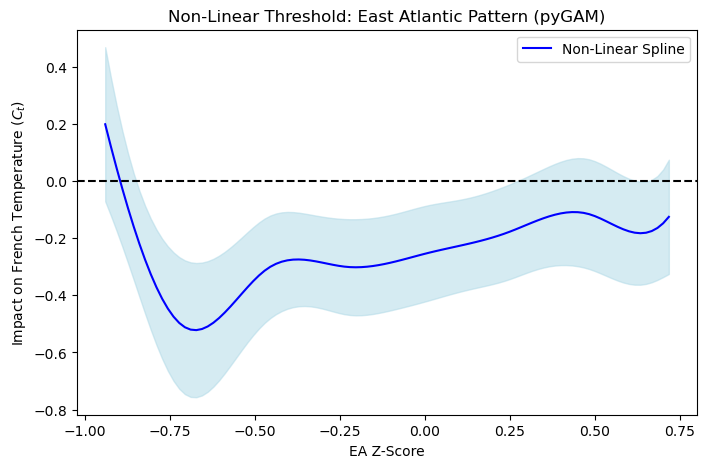

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, l

# ==============================================================================
# 1. PREPARE THE PYTHON ENVIRONMENT
# ==============================================================================
# Assume df_ortho is your pandas DataFrame. Drop any NaN rows first.
df_gam = df_climate[:912].dropna().copy()

# Define the feature matrix (X) and the target vector (y)
# Index 0: NAO_Lag0, Index 1: NAO_Lag135, Index 2: EA_Lag0
X = df_gam[['filt_nao', 'NAO_Lag_135', 'filt_ea']].values
y = df_gam['filt_cycle']

# ==============================================================================
# 2. EXECUTE THE SPLINE PHYSICS
# ==============================================================================
# The GAM Architecture:
# s(0): Non-linear spline for instantaneous wind
# l(1): Strictly linear relationship for the oceanic gyre (stationary assumption)
# s(2): Non-linear spline for the East Atlantic pattern (to map the cold funnel)
master_gam = LinearGAM(s(0, n_splines=10) + s(1, n_splines=10))
master_gam.gridsearch(X, y) # Autonomously finds the optimal smoothness penalty

# Output the statistical diagnostic summary
print(master_gam.summary())

# ==============================================================================
# 3. PLOT THE NON-LINEAR THRESHOLDS
# ==============================================================================
# We plot the partial dependence function for the East Atlantic parameter (feature index 2)
# to physically see the geometry of the atmospheric threshold.
XX = master_gam.generate_X_grid(term=1)
pdep, confi = master_gam.partial_dependence(term=1, X=XX, width=.95)

plt.figure(figsize=(8, 5))
# Plot the isolated effect
plt.plot(XX[:, 1], pdep, color='blue', label='Non-Linear Spline')
# Plot the 95% confidence intervals
plt.fill_between(XX[:, 1], confi[:, 0], confi[:, 1], color='lightblue', alpha=0.5)

plt.title('Non-Linear Threshold: East Atlantic Pattern (pyGAM)')
plt.xlabel('EA Z-Score')
plt.ylabel('Impact on French Temperature ($C_t$)')
plt.axhline(0, color='black', linestyle='--')
plt.legend()
plt.show()

In [27]:
df_sca = pd.read_csv("demo_france/SCA.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)

# Load East Atlantic Pattern
df_amo = pd.read_csv("demo_france/AMO.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_172174/1385202438.py:1: SyntaxWarning: invalid escape sequence '\s'
  df_sca = pd.read_csv("demo_france/SCA.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)
/tmp/ipykernel_172174/1385202438.py:4: SyntaxWarning: invalid escape sequence '\s'
  df_amo = pd.read_csv("demo_france/AMO.txt", sep='\s+', na_values=[-99.9, -99.90], header=None)


In [28]:
import pandas as pd
import numpy as np

# ==============================================================================
# 1. DYNAMIC COLUMN MAPPING
# ==============================================================================
# Reset the index to ensure no data is hidden in the index structure
df_raw = df_sca
df_raw = df_raw.reset_index(drop=True)

# Dynamically assess the shape of the imported matrix
num_cols = df_raw.shape[1]

if num_cols == 14:
    # Condition A: The arbitrary index (0, 1, 2) was parsed as a data column
    df_raw.columns = ['Drop_Index', 'Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    df_clean = df_raw.drop(columns=['Drop_Index'])
elif num_cols == 13:
    # Condition B: The data parsed strictly as Year + 12 Months
    df_raw.columns = ['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    df_clean = df_raw.copy()
else:
    raise ValueError(f"Matrix Dimension Error: Expected 13 or 14 columns, but detected {num_cols}.")

# ==============================================================================
# 2. CLEANING THE DATA MATRIX
# ==============================================================================
# Remove the faulty row and replace placeholders
# We force 'Year' to numeric first to ensure strict equality checking
df_clean['Year'] = pd.to_numeric(df_clean['Year'], errors='coerce')
df_clean = df_clean.dropna(subset=['Year']) # Drop if the header row was imported as data
df_clean = df_clean[df_clean['Year'] != -9999]
df_clean = df_clean.replace(-9999.00, np.nan)

# ==============================================================================
# 3. STRUCTURAL TRANSFORMATION (WIDE TO LONG)
# ==============================================================================
# Melt the dataframe: Year remains the identifier, months become a variable column
df_long = df_clean.melt(id_vars=['Year'], var_name='Month', value_name='Target_Value')

# Map string months to integers for datetime conversion
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
df_long['Month_Num'] = df_long['Month'].map(month_map)

# ==============================================================================
# 4. TIME SERIES INDEXING
# ==============================================================================
# Construct standard Datetime objects (YYYY-MM-01)
# Ensure Year is strictly an integer string for the datetime parser
df_long['Date'] = pd.to_datetime(
    df_long['Year'].astype(int).astype(str) + '-' + 
    df_long['Month_Num'].astype(str) + '-01'
)

# Sort chronologically
df_ts = df_long.sort_values('Date')

# Set the Date as the index and isolate the single dimension
df_1d = df_ts.set_index('Date')[['Target_Value']]

# Drop the future unrecorded months
df_final = df_1d.dropna()

print(df_final.head())

            Target_Value
Date                    
1950-01-01          0.78
1950-02-01         -0.94
1950-03-01         -0.22
1950-04-01          0.46
1950-05-01          0.28


In [29]:
df_final

,Target_Value
Date,
1950-01-01,0.78
1950-02-01,-0.94
1950-03-01,-0.22
1950-04-01,0.46
1950-05-01,0.28
...,...
2025-01-01,-0.72
2025-02-01,1.38
2025-03-01,-0.18


In [14]:
df_amo[2]

0     -0.03
1     -0.13
2     -0.16
3     -0.22
4     -0.23
       ... 
907    0.83
908    0.76
909    1.01
910    0.96
911    0.75
Name: 2, Length: 912, dtype: float64

In [15]:
df_climate = df_climate[:905]

In [17]:
df_climate

,NAO,EA,raw,SCA,AMO
Date,,,,,
1950-01-01,0.9200,-2.71,2.148903,0.78,NaN
1950-02-01,0.4000,0.66,5.969903,-0.94,NaN
1950-03-01,-0.3600,0.82,7.083308,-0.22,NaN
1950-04-01,0.7300,0.28,8.031222,0.46,NaN
1950-05-01,-0.5900,-0.51,13.992700,0.28,NaN
...,...,...,...,...,...
2025-01-01,-0.5224,2.70,4.451415,-0.72,NaN
2025-02-01,1.5958,0.65,5.495558,1.38,NaN
2025-03-01,0.2999,0.81,7.924747,-0.18,NaN


In [31]:
df_climate

,NAO,EA,raw,SCA,AMO
Date,,,,,
1950-01-01,0.9200,-2.71,2.148903,0.78,-0.03
1950-02-01,0.4000,0.66,5.969903,-0.94,-0.13
1950-03-01,-0.3600,0.82,7.083308,-0.22,-0.16
1950-04-01,0.7300,0.28,8.031222,0.46,-0.22
1950-05-01,-0.5900,-0.51,13.992700,0.28,-0.23
...,...,...,...,...,...
2025-01-01,-0.5224,2.70,4.451415,-0.72,0.98
2025-02-01,1.5958,0.65,5.495558,1.38,0.86
2025-03-01,0.2999,0.81,7.924747,-0.18,0.75


In [30]:
df_climate['AMO'] = df_amo[2][:905].values

In [113]:
import numpy as np
import pandas as pd
from PyEMD import CEEMDAN

def extract_ceemdan_cycle(time_series, imf_indices_to_keep, trials=100, epsilon=0.2):
    """
    Executes CEEMDAN on a 1D time series and reconstructs the signal 
    using only a specified subset of Intrinsic Mode Functions (IMFs).
    
    Parameters:
    time_series (ndarray or Series): The raw 1D input data.
    imf_indices_to_keep (list): The integer indices of the IMFs to sum 
                                (e.g., [4, 5] for the 5th and 6th IMFs).
    trials (int): Ensemble size. 100 is optimal for CEEMDAN.
    epsilon (float): Standard deviation of added noise relative to the signal.
    
    Returns:
    ndarray: The reconstructed time series isolating the specific frequencies.
    ndarray: The full matrix of all extracted IMFs for diagnostic review.
    """
    # 1. Initialize data and CEEMDAN instance
    s = np.array(time_series)
    ceemdan = CEEMDAN()
    ceemdan.trials = trials
    ceemdan.epsilon = epsilon * np.std(s)
    
    # 2. Execute Decomposition
    print(f"Executing CEEMDAN... (Length: {len(s)})")
    all_imfs = ceemdan(s)
    
    # 3. Signal Reconstruction
    # Initialize an array of zeros with the same length as the input
    reconstructed_cycle = np.zeros(len(s))
    
    # Algebraically sum the selected low-frequency IMFs
    for idx in imf_indices_to_keep:
        if idx < all_imfs.shape[0] - 1: # Ensure we don't index out of bounds or grab the residual
            reconstructed_cycle += all_imfs[idx]
        else:
            print(f"Warning: IMF index {idx} exceeds extracted modes.")
            
    return reconstructed_cycle, all_imfs

# ==============================================================================
# EXECUTION AND RECONSTRUCTION
# ==============================================================================
# Assume df_climate contains your raw data: 'Y' (Temp), 'NAO', 'EA'
# You MUST determine the correct IMFs to keep based on visual or spectral analysis.
# Based on your previous cross-correlation graphs, IMF 5 and IMF 6 generally 
# capture the 8-to-12 year decadal cycles. We use 0-based indexing in Python (4 and 5).

target_imfs = [-2, -3, -4] 
amo_cycle, amo_all_imfs = extract_ceemdan_cycle(df_climate['AMO'], target_imfs)
print("Processing Target Temperature (Y)...")
y_cycle, y_all_imfs = extract_ceemdan_cycle(df_climate['raw'], target_imfs)

print("Processing North Atlantic Oscillation (NAO)...")
nao_cycle, nao_all_imfs = extract_ceemdan_cycle(df_climate['NAO'], target_imfs)

print("Processing East Atlantic Pattern (EA)...")
ea_cycle, ea_all_imfs = extract_ceemdan_cycle(df_climate['EA'], target_imfs)

sca_cycle, sca_all_imfs = extract_ceemdan_cycle(df_climate['SCA'], target_imfs)



# ==============================================================================
# REBUILDING THE GAM FEATURE MATRIX
# ==============================================================================
# Insert the non-stationary, low-frequency cycles back into a new DataFrame
df_gam_filtered = pd.DataFrame({
    'Temp_Cycle': y_cycle,
    'NAO_Cycle': nao_cycle,
    'EA_Cycle': ea_cycle,
    'SCA_Cycle': sca_cycle,
    'AMO_Cycle': amo_cycle,
    'Global_Warming': y_all_imfs[-1] - np.mean(y_all_imfs[-1])
})

# Define the feature matrix (X) and target (y) for the PyGAM tensor architecture
X_ceemdan = df_gam_filtered[['NAO_Cycle', 'EA_Cycle', 'SCA_Cycle', 'AMO_Cycle']].values
y_ceemdan = df_gam_filtered['Temp_Cycle'].values

print("\nCEEMDAN Data Engineering Complete. Ready for GAM Tensor Integration.")

Executing CEEMDAN... (Length: 905)


Processing Target Temperature (Y)...
Executing CEEMDAN... (Length: 905)
Processing North Atlantic Oscillation (NAO)...
Executing CEEMDAN... (Length: 905)
Processing East Atlantic Pattern (EA)...
Executing CEEMDAN... (Length: 905)
Executing CEEMDAN... (Length: 905)

CEEMDAN Data Engineering Complete. Ready for GAM Tensor Integration.


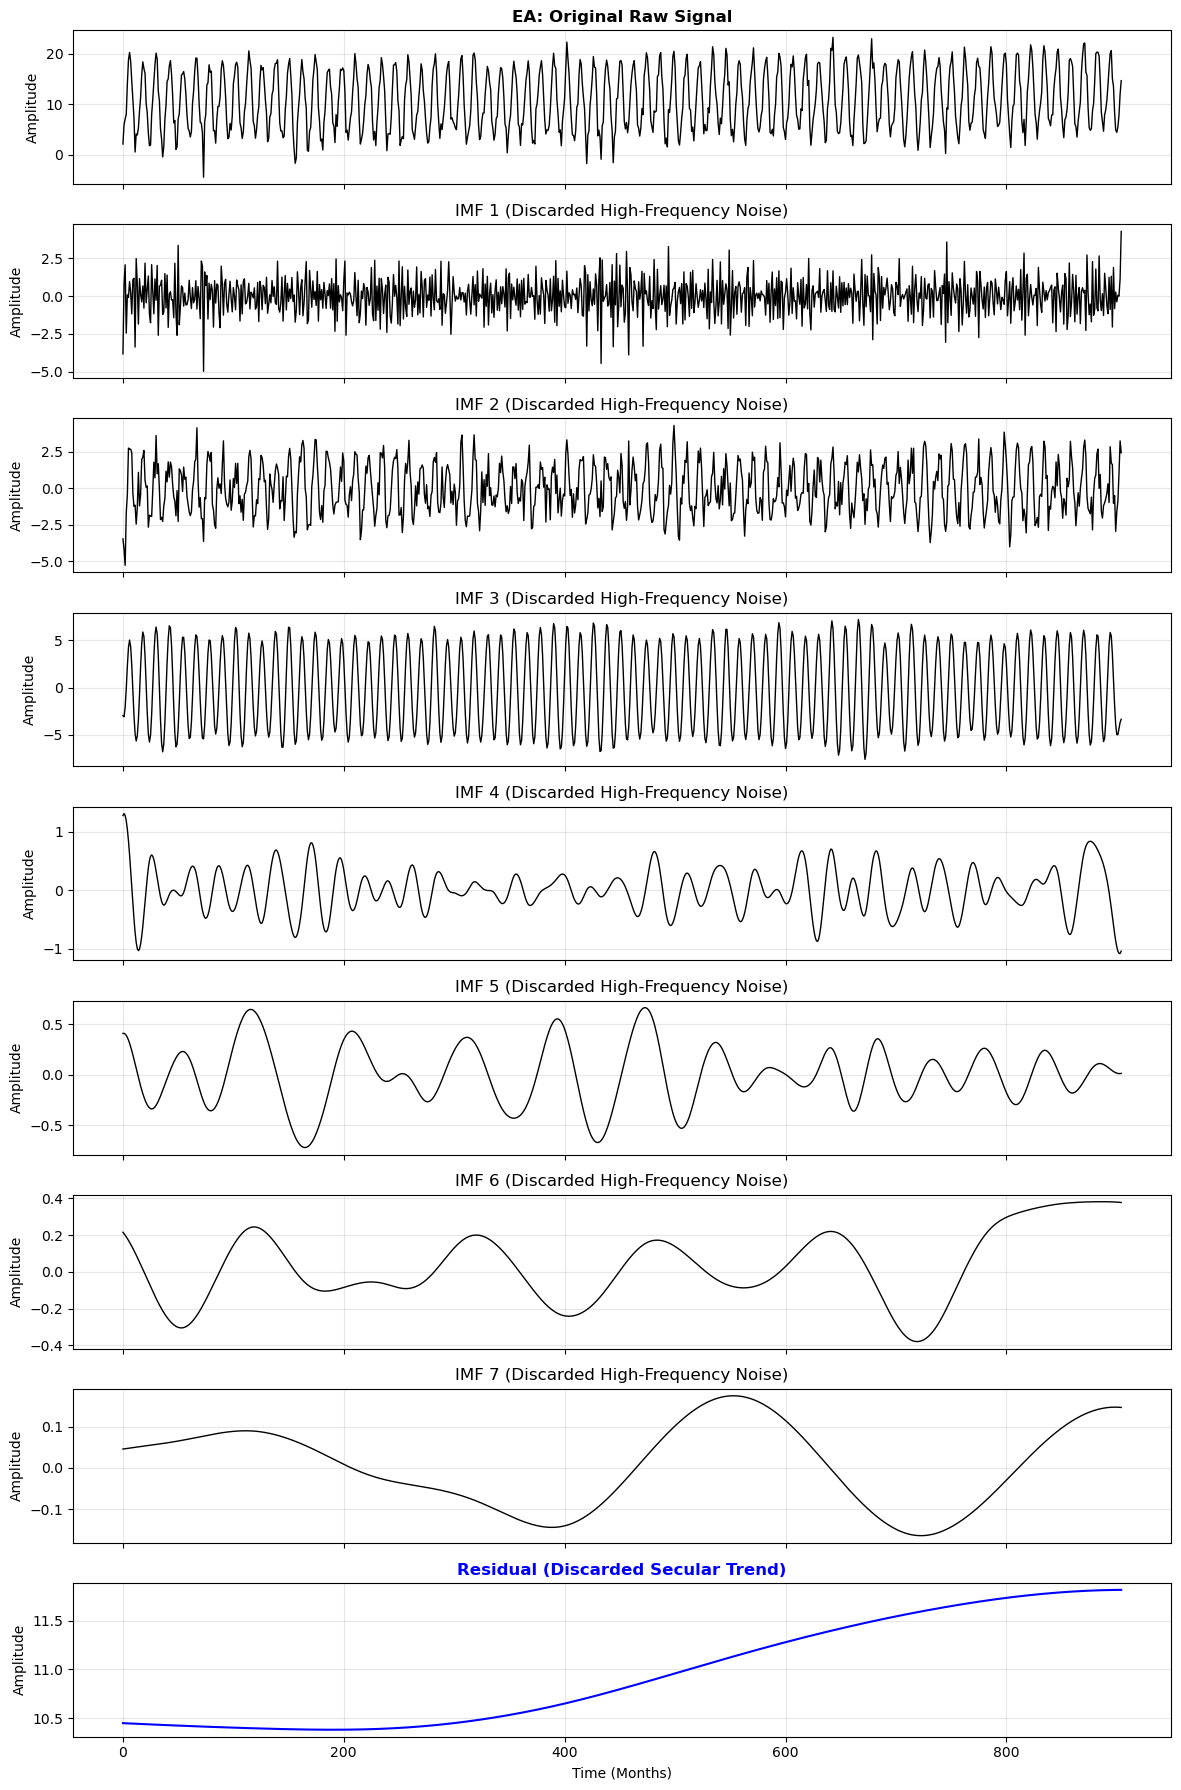

In [133]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ceemdan_decomposition(original_series, all_imfs, extracted_indices, title_prefix="Variable"):
    """
    Plots the full CEEMDAN decomposition matrix, highlighting the specific 
    low-frequency IMFs that were extracted to build the cyclic feature matrix.
    
    Parameters:
    original_series (ndarray): The raw 1D input data.
    all_imfs (ndarray): The 2D array output from PyEMD (IMFs + Residual).
    extracted_indices (list): The Python indices (0-based) of the targeted IMFs.
    title_prefix (str): Label for the specific variable being plotted.
    """
    # The last row of the matrix is strictly the residual, not an IMF
    num_imfs = all_imfs.shape[0] - 1 
    time_axis = np.arange(len(original_series))
    
    # Create a dynamic figure height based on the number of extracted modes
    fig, axes = plt.subplots(num_imfs + 2, 1, figsize=(12, 2 * (num_imfs + 2)), sharex=True)
    
    # ==============================================================================
    # 1. Plot the Original Raw Signal
    # ==============================================================================
    axes[0].plot(time_axis, original_series, color='black', linewidth=1)
    axes[0].set_title(f"{title_prefix}: Original Raw Signal", fontweight='bold')
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(True, alpha=0.3)
    
    # ==============================================================================
    # 2. Plot the Intrinsic Mode Functions (IMFs)
    # ==============================================================================
    for i in range(num_imfs):
        ax = axes[i + 1]
        
        # Check if this specific IMF is part of your target cyclic reconstruction
        if i in extracted_indices:
            color = 'red'
            linewidth = 2.0
            # Note: Adding 1 to 'i' maps 0-based Python indexing to standard 1-based IMF literature
            title = f"IMF {i + 1} (EXTRACTED TARGET CYCLE)" 
            ax.set_title(title, color=color, fontweight='bold')
        else:
            color = 'black'
            linewidth = 1.0
            title = f"IMF {i + 1} (Discarded High-Frequency Noise)"
            ax.set_title(title)
            
        ax.plot(time_axis, all_imfs[i], color=color, linewidth=linewidth)
        ax.set_ylabel("Amplitude")
        ax.grid(True, alpha=0.3)
    
    # ==============================================================================
    # 3. Plot the Non-Stationary Residual
    # ==============================================================================
    axes[-1].plot(time_axis, all_imfs[-1], color='blue', linewidth=1.5)
    axes[-1].set_title("Residual (Discarded Secular Trend)", color='blue', fontweight='bold')
    axes[-1].set_xlabel("Time (Months)")
    axes[-1].set_ylabel("Amplitude")
    axes[-1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ==============================================================================
# EXECUTION
# ==============================================================================
# Execute this function for each of your preprocessed variables.
# For example, to plot the North Atlantic Oscillation decomposition:

# target_imfs = [4, 5]  # Python indices for IMF 5 and IMF 6
#plot_ceemdan_decomposition(df_climate['NAO'].values, nao_all_imfs, target_imfs, title_prefix="NAO")
#plot_ceemdan_decomposition(df_climate['EA'].values, ea_all_imfs, target_imfs, title_prefix="EA")
plot_ceemdan_decomposition(df_climate['raw'].values, y_all_imfs, target_imfs, title_prefix="EA")
#plot_ceemdan_decomposition(df_climate['AMO'].values, amo_all_imfs, target_imfs, title_prefix="AMO")

In [39]:
df_climate

,NAO,EA,raw,SCA,AMO
Date,,,,,
1950-01-01,0.9200,-2.71,2.148903,0.78,-0.03
1950-02-01,0.4000,0.66,5.969903,-0.94,-0.13
1950-03-01,-0.3600,0.82,7.083308,-0.22,-0.16
1950-04-01,0.7300,0.28,8.031222,0.46,-0.22
1950-05-01,-0.5900,-0.51,13.992700,0.28,-0.23
...,...,...,...,...,...
2025-01-01,-0.5224,2.70,4.451415,-0.72,0.98
2025-02-01,1.5958,0.65,5.495558,1.38,0.86
2025-03-01,0.2999,0.81,7.924747,-0.18,0.75


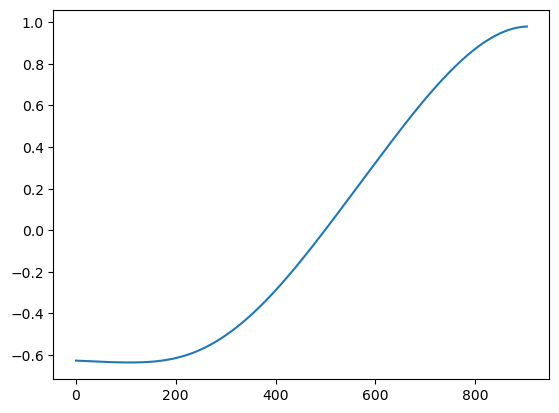

In [83]:
plt.plot(range(905), df_gam_filtered['Global_Warming'])

Executing Exhaustive Cross-Correlation (±150 months)...

--- EXHAUSTIVE LAG SUMMARY MATRIX ---
              Pairing  Peak Correlation (r)  Optimal Lag (Months)          Physical Dynamic
 NAO_Cycle & EA_Cycle                0.3627                    67  NAO_Cycle LEADS EA_Cycle
NAO_Cycle & SCA_Cycle                0.3552                   150 NAO_Cycle LEADS SCA_Cycle
 EA_Cycle & AMO_Cycle                0.3548                     0       Synchronous (0 Lag)
 EA_Cycle & SCA_Cycle               -0.3459                   -39  SCA_Cycle LEADS EA_Cycle
SCA_Cycle & AMO_Cycle                0.3036                    88 SCA_Cycle LEADS AMO_Cycle
NAO_Cycle & AMO_Cycle                0.2912                   -70 AMO_Cycle LEADS NAO_Cycle


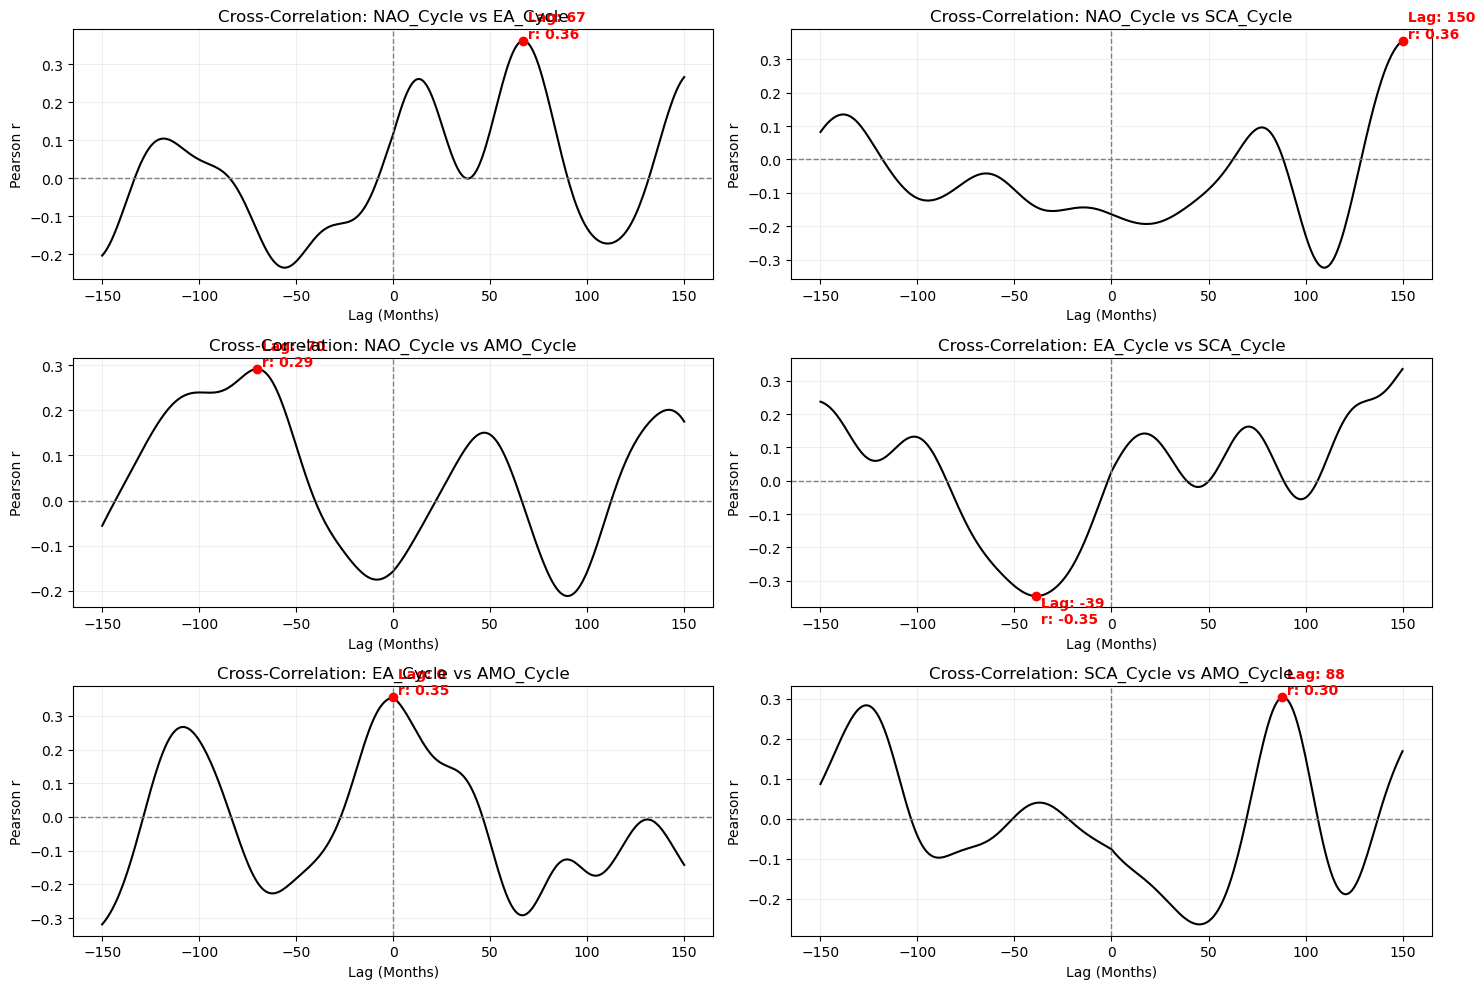

In [261]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

def exhaustive_lag_correlation(df, variables, max_lag=150):
    """
    Computes the Pearson correlation between all pairs of variables across a 
    sliding temporal window to identify the exact lag of maximum coupling.
    
    Parameters:
    df (DataFrame): The dataset containing the CEEMDAN-filtered cycles.
    variables (list): List of column names to cross-correlate.
    max_lag (int): The maximum number of months to shift forward and backward.
    """
    # Generate all unique pairs of variables
    pairs = list(itertools.combinations(variables, 2))
    
    # Initialize a dictionary to store the full correlation arrays for plotting
    cross_corr_data = {}
    
    # Initialize a list to store the summary statistics
    summary_stats = []
    
    # Define the lag axis (-max_lag to +max_lag)
    lags = np.arange(-max_lag, max_lag + 1)
    
    print(f"Executing Exhaustive Cross-Correlation (±{max_lag} months)...")
    
    for var1, var2 in pairs:
        correlations = []
        
        for lag in lags:
            # Shift var2 relative to var1. 
            # A positive lag means var1 precedes (leads) var2.
            # A negative lag means var2 precedes (leads) var1.
            shifted_var2 = df[var2].shift(lag)
            
            # Calculate Pearson correlation, dropping the NaNs created by the shift
            corr = df[var1].corr(shifted_var2)
            correlations.append(corr)
            
        correlations = np.array(correlations)
        cross_corr_data[f"{var1} vs {var2}"] = correlations
        
        # Identify the absolute maximum coupling (can be strong negative or positive)
        max_abs_idx = np.argmax(np.abs(correlations))
        peak_corr = correlations[max_abs_idx]
        optimal_lag = lags[max_abs_idx]
        
        # Determine physical causality direction based on the lag sign
        if optimal_lag > 0:
            direction = f"{var1} LEADS {var2}"
        elif optimal_lag < 0:
            direction = f"{var2} LEADS {var1}"
        else:
            direction = "Synchronous (0 Lag)"
            
        summary_stats.append({
            "Pairing": f"{var1} & {var2}",
            "Peak Correlation (r)": round(peak_corr, 4),
            "Optimal Lag (Months)": optimal_lag,
            "Physical Dynamic": direction
        })
        
    # Compile the summary into a DataFrame
    df_summary = pd.DataFrame(summary_stats).sort_values(by="Peak Correlation (r)", key=abs, ascending=False)
    
    return df_summary, cross_corr_data, lags

# ==============================================================================
# EXECUTION
# ==============================================================================
# Assuming df_gam_filtered contains your CEEMDAN extracted cycles
variables_to_test = ['NAO_Cycle', 'EA_Cycle', 'SCA_Cycle', 'AMO_Cycle']

# Execute the test up to 150 months (12.5 years)
df_lag_summary, cross_corr_data, lag_axis = exhaustive_lag_correlation(df_gam_filtered, variables_to_test, max_lag=150)

# Output the definitive mathematical summary
print("\n--- EXHAUSTIVE LAG SUMMARY MATRIX ---")
print(df_lag_summary.to_string(index=False))

# ==============================================================================
# VISUALIZATION: THE CROSS-CORRELATION SPECTRA
# ==============================================================================
plt.figure(figsize=(15, 10))

for i, (pair_name, corr_array) in enumerate(cross_corr_data.items(), 1):
    plt.subplot(3, 2, i)
    plt.plot(lag_axis, corr_array, color='black', linewidth=1.5)
    
    # Highlight the zero-lag baseline
    plt.axvline(0, color='gray', linestyle='--', linewidth=1)
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    
    # Highlight the absolute peak
    max_idx = np.argmax(np.abs(corr_array))
    plt.plot(lag_axis[max_idx], corr_array[max_idx], 'ro')
    plt.text(lag_axis[max_idx], corr_array[max_idx], f' Lag: {lag_axis[max_idx]}\n r: {corr_array[max_idx]:.2f}', 
             color='red', fontweight='bold', va='bottom' if corr_array[max_idx] > 0 else 'top')
    
    plt.title(f"Cross-Correlation: {pair_name}")
    plt.xlabel("Lag (Months)")
    plt.ylabel("Pearson r")
    plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

Executing Target Correlation against Temp_Cycle (±120 months)...

--- TARGET LAG SUMMARY ---
Predictor     Target  Peak Correlation (r)  Optimal Lag (Months)             Physical Dynamic
AMO_Cycle Temp_Cycle               -0.4073                    45 AMO_Cycle LEADS (Predictive)
NAO_Cycle Temp_Cycle                0.3075                     0          Synchronous (0 Lag)
SCA_Cycle Temp_Cycle               -0.2328                    36 SCA_Cycle LEADS (Predictive)
 EA_Cycle Temp_Cycle                0.1893                     0          Synchronous (0 Lag)


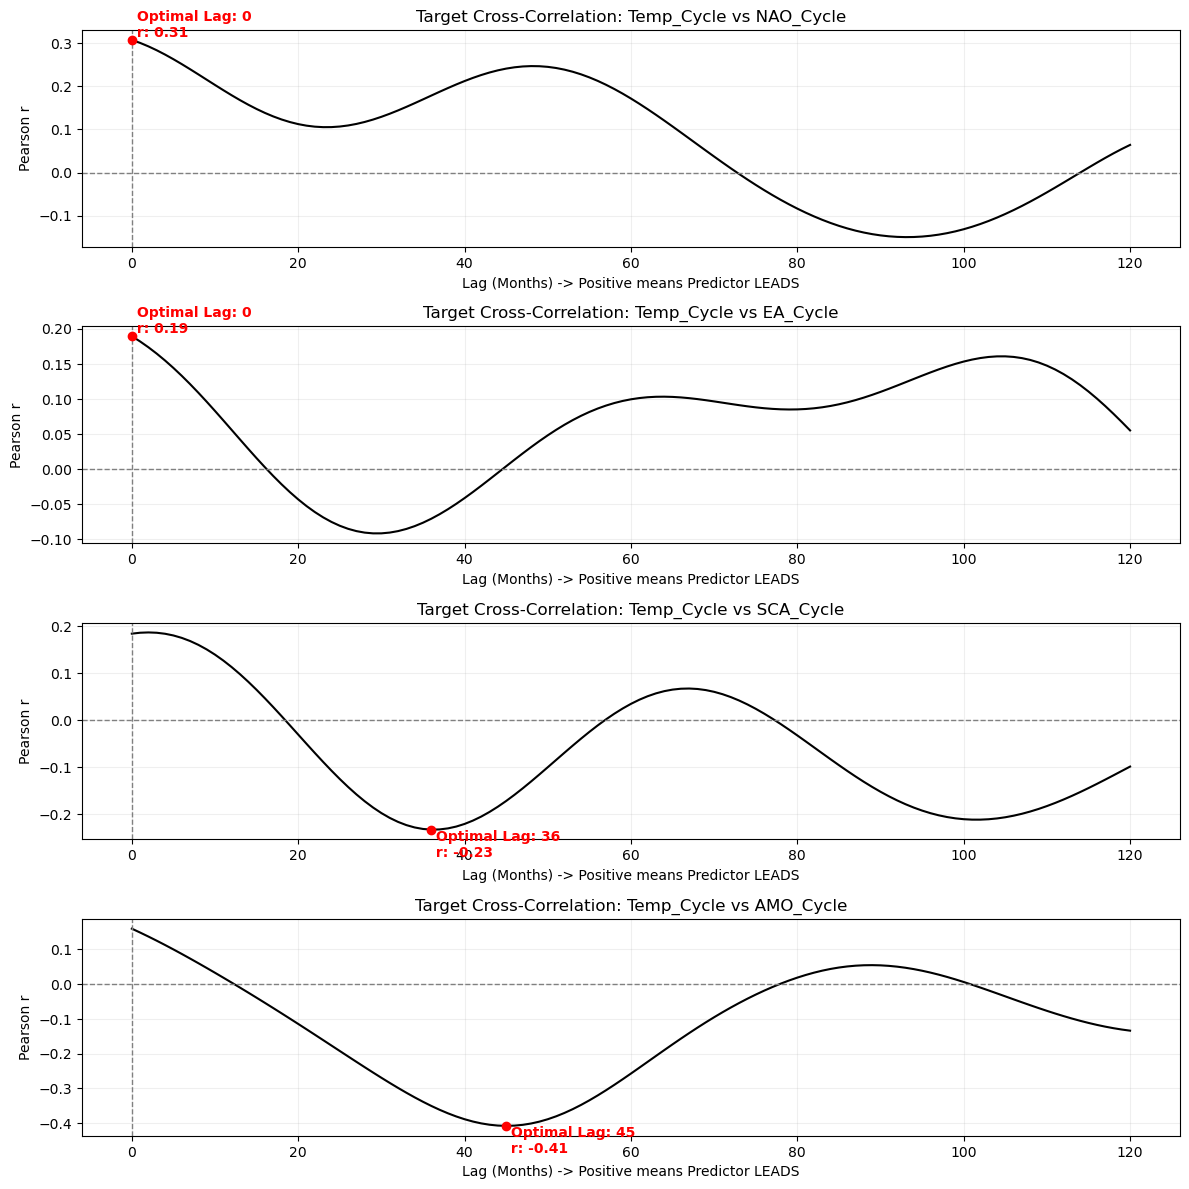

In [181]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def target_lag_correlation(df, target_var, predictors, max_lag=150):
    """
    Computes the cross-correlation between a fixed target variable and multiple 
    predictor variables to identify the optimal predictive lag.
    
    Parameters:
    df (DataFrame): Dataset containing the CEEMDAN-filtered cycles.
    target_var (str): The dependent variable (e.g., 'Temp_Cycle').
    predictors (list): List of independent variables to slide against the target.
    max_lag (int): Maximum temporal shift in months.
    """
    cross_corr_data = {}
    summary_stats = []
    lags = np.arange(0, max_lag + 1)
    
    print(f"Executing Target Correlation against {target_var} (±{max_lag} months)...")
    
    for predictor in predictors:
        correlations = []
        
        for lag in lags:
            # Shift the predictor. 
            # A POSITIVE lag means the predictor's past is aligned with the target's present.
            # Therefore, a positive optimal lag = The predictor LEADS the temperature.
            shifted_predictor = df[predictor].shift(lag)
            
            # Compute Pearson r, dropping NaNs created by the temporal shift
            corr = df[target_var].corr(shifted_predictor)
            correlations.append(corr)
            
        correlations = np.array(correlations)
        cross_corr_data[predictor] = correlations
        
        # Isolate the absolute maximum correlation
        max_abs_idx = np.argmax(np.abs(correlations))
        peak_corr = correlations[max_abs_idx]
        optimal_lag = lags[max_abs_idx]
        
        # Determine causality
        if optimal_lag > 0:
            causality = f"{predictor} LEADS (Predictive)"
        elif optimal_lag < 0:
            causality = f"Temperature LEADS (Non-Predictive / Feedback)"
        else:
            causality = "Synchronous (0 Lag)"
            
        summary_stats.append({
            "Predictor": predictor,
            "Target": target_var,
            "Peak Correlation (r)": round(peak_corr, 4),
            "Optimal Lag (Months)": optimal_lag,
            "Physical Dynamic": causality
        })
        
    df_summary = pd.DataFrame(summary_stats).sort_values(by="Peak Correlation (r)", key=abs, ascending=False)
    
    return df_summary, cross_corr_data, lags

# ==============================================================================
# EXECUTION
# ==============================================================================
target = 'Temp_Cycle'
predictors_to_test = ['NAO_Cycle', 'EA_Cycle', 'SCA_Cycle', 'AMO_Cycle']

# Execute the target correlation analysis
df_target_summary, target_corr_data, lag_axis = target_lag_correlation(df_gam_filtered, target, predictors_to_test, max_lag=120)

# Output the mathematical summary
print("\n--- TARGET LAG SUMMARY ---")
print(df_target_summary.to_string(index=False))

# ==============================================================================
# VISUALIZATION
# ==============================================================================
num_plots = len(predictors_to_test)
plt.figure(figsize=(12, 3 * num_plots))

for i, (predictor, corr_array) in enumerate(target_corr_data.items(), 1):
    plt.subplot(num_plots, 1, i)
    plt.plot(lag_axis, corr_array, color='black', linewidth=1.5)
    
    # Baselines
    plt.axvline(0, color='gray', linestyle='--', linewidth=1)
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    
    # Highlight Peak
    max_idx = np.argmax(np.abs(corr_array))
    peak_lag = lag_axis[max_idx]
    peak_r = corr_array[max_idx]
    
    plt.plot(peak_lag, peak_r, 'ro')
    plt.text(peak_lag, peak_r, f' Optimal Lag: {peak_lag}\n r: {peak_r:.2f}', 
             color='red', fontweight='bold', 
             va='bottom' if peak_r > 0 else 'top')
    
    plt.title(f"Target Cross-Correlation: {target} vs {predictor}")
    plt.xlabel("Lag (Months) -> Positive means Predictor LEADS")
    plt.ylabel("Pearson r")
    plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

Total lag combinations to test: 6561
Aligning all matrices to universal max lag limit: 160 months...
------------------------------------------------------------
Executing Multi-Architecture Global Lag Test (65610 total fits)...
[100/65610] Processed. Current Best BIC: -106.03
[200/65610] Processed. Current Best BIC: -155.75
[300/65610] Processed. Current Best BIC: -347.72
[400/65610] Processed. Current Best BIC: -398.5
[500/65610] Processed. Current Best BIC: -398.5
[600/65610] Processed. Current Best BIC: -398.5
[700/65610] Processed. Current Best BIC: -398.5
[800/65610] Processed. Current Best BIC: -398.5
[900/65610] Processed. Current Best BIC: -398.5
[1000/65610] Processed. Current Best BIC: -398.5
[1100/65610] Processed. Current Best BIC: -398.5
[1200/65610] Processed. Current Best BIC: -398.5
[1300/65610] Processed. Current Best BIC: -398.5
[1400/65610] Processed. Current Best BIC: -398.5
[1500/65610] Processed. Current Best BIC: -398.5
[1600/65610] Processed. Current Best BIC: 

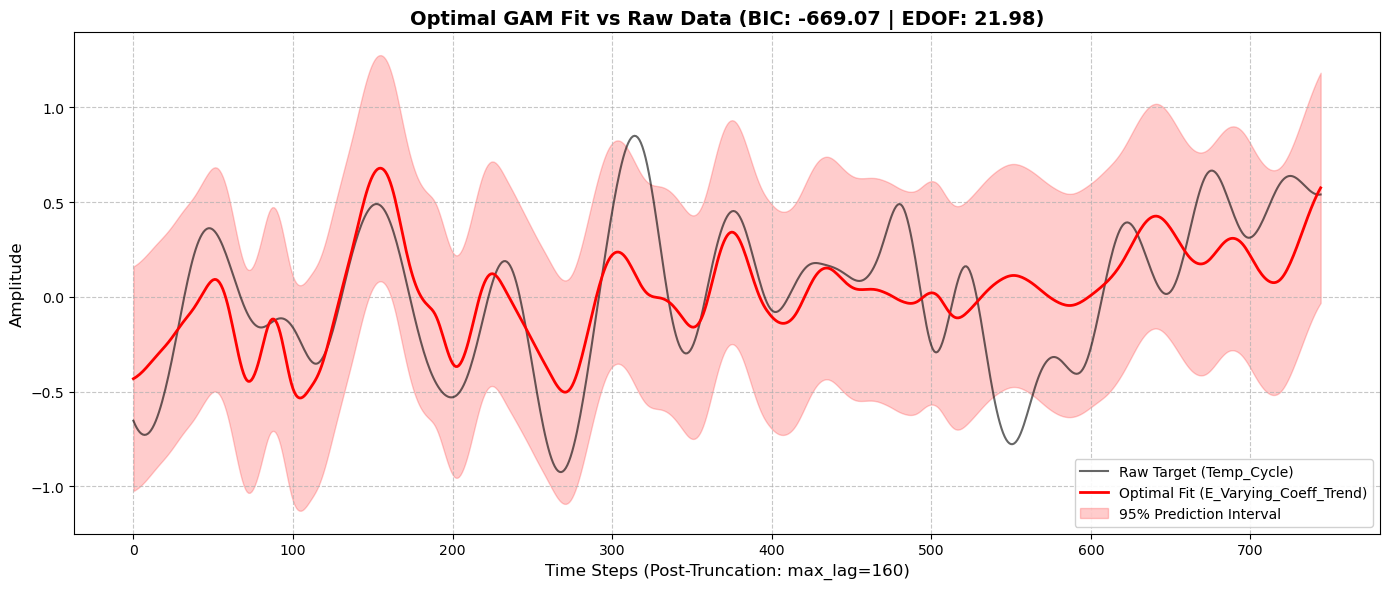

In [118]:
import pandas as pd
import numpy as np
import itertools
from pygam import LinearGAM, l, s, te
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. PARAMETERS AND LAG GRID DEFINITION
# ==============================================================================
lag_steps = [0,1,2,6,30, 60,90, 120, 160] 
lag_combinations = list(itertools.product(lag_steps, repeat=4))
max_lag = max(lag_steps)

print(f"Total lag combinations to test: {len(lag_combinations)}")
print(f"Aligning all matrices to universal max lag limit: {max_lag} months...")

# Extract pure raw vectors
nao_raw = df_gam_filtered['NAO_Cycle'].values
ea_raw = df_gam_filtered['EA_Cycle'].values
sca_raw = df_gam_filtered['SCA_Cycle'].values
amo_raw = df_gam_filtered['AMO_Cycle'].values
y_raw = df_gam_filtered['Temp_Cycle'].values
trend_raw = df_gam_filtered['Global_Warming'].values 

# Stationary targets
y_base = y_raw[max_lag:]
trend_base = trend_raw[max_lag:]
n_samples = len(y_base)

# ==============================================================================
# 2. ARCHITECTURE DEFINITIONS
# ==============================================================================
# We define a dictionary of formulations to test exhaustively.
# Spline degrees and basis functions are kept minimal to enforce simplicity.

formulations = {
    "A_Strict_Linear": l(0) + l(1) + l(2) + l(3) + l(4),
    
    "B_Linear_Cycles_Spline_Trend": l(0) + l(1) + l(2) + l(3) + s(4, spline_order=2, n_splines=5),
    
    "C_Strict_Splines": s(0, spline_order=2, n_splines=5) + 
                        s(1, spline_order=2, n_splines=5) + 
                        s(2, spline_order=2, n_splines=5) + 
                        s(3, spline_order=2, n_splines=5) + 
                        s(4, spline_order=2, n_splines=5),
                        
    "D_Trend_Dependent_Tensors": te(0, 4, n_splines=(4, 4)) + 
                                 te(1, 4, n_splines=(4, 4)) + 
                                 te(2, 4, n_splines=(4, 4)) + 
                                 te(3, 4, n_splines=(4, 4)),

"E_Varying_Coeff_Trend": l(0) + l(1) + l(2) + l(3) + s(4, n_splines=5) + 
                             s(4, by=0, n_splines=5) + 
                             s(4, by=1, n_splines=5) + 
                             s(4, by=2, n_splines=5) + 
                             s(4, by=3, n_splines=5),
                             
    # F. Teleconnection Coupling: Interaction between specific atmospheric/oceanic variables
    # 0 (NAO) couples with 1 (EA); 2 (SCA) couples with 3 (AMO)
    "F_Teleconnection_Coupling": te(0, 1, n_splines=(4, 4)) + 
                                 te(2, 3, n_splines=(4, 4)) + 
                                 l(4),
                                 
    # G. Mixed Dynamics: Fast Atmospheric (Linear) vs Slow Oceanic/Thermodynamic (Spline)
    "G_Mixed_Fast_Slow": l(0) + l(1) + l(2) + 
                         s(3, spline_order=2, n_splines=5) + 
                         s(4, spline_order=2, n_splines=5),    
    "H_Selective_VC_Modulation": l(0) + l(1) + l(2) + l(3) + s(4, n_splines=5) + 
                                 s(4, by=0, n_splines=5) + 
                                 s(4, by=1, n_splines=5) + 
                                 s(4, by=3, n_splines=5),
                                 
    # I. Stiff Varying Coefficients: Force the trend spline to be rigid (spline_order=1, min splines)
    "I_Stiff_VC_Trend": l(0) + l(1) + l(2) + l(3) + s(4, spline_order=1, n_splines=4) + 
                        s(4, by=0, spline_order=1, n_splines=4) + 
                        s(4, by=1, spline_order=1, n_splines=4) + 
                        s(4, by=2, spline_order=1, n_splines=4) + 
                        s(4, by=3, spline_order=1, n_splines=4),

    # J. Coupled NAO/EA Surface + Modulated AMO: 
    # NAO(0) and EA(1) as a 2D tensor; AMO(3) modulated by the Trend(4)
    "J_Coupled_NAO_EA_Modulated": te(0, 1, n_splines=(4, 4)) + l(2) + l(3) + 
                                  s(4, n_splines=5) + s(4, by=3, n_splines=5)
    
    
}

# ==============================================================================
# 3. EXHAUSTIVE GRID SEARCH EXECUTION
# ==============================================================================
results = []
total_tests = len(lag_combinations) * len(formulations)
current_test = 0

print("-" * 60)
print(f"Executing Multi-Architecture Global Lag Test ({total_tests} total fits)...")

for nao_lag, ea_lag, sca_lag, amo_lag in lag_combinations:
    
    # Shift variables
    nao_shifted = pd.Series(nao_raw).shift(nao_lag).values[max_lag:]
    ea_shifted  = pd.Series(ea_raw).shift(ea_lag).values[max_lag:]
    sca_shifted = pd.Series(sca_raw).shift(sca_lag).values[max_lag:]
    amo_shifted = pd.Series(amo_raw).shift(amo_lag).values[max_lag:]
    
    X_matrix = np.column_stack((nao_shifted, ea_shifted, sca_shifted, amo_shifted, trend_base))
        
    for form_name, formulation in formulations.items():
        current_test += 1
        
        try:
            model = LinearGAM(formulation)
            model.gridsearch(X_matrix, y_base, progress=False)
            
            aic = model.statistics_['AIC']
            edof = model.statistics_['edof']
            bic = aic + edof * (np.log(n_samples) - 2)
            
            results.append({
                "Model_Architecture": form_name,
                "NAO_Lag": nao_lag,
                "EA_Lag": ea_lag,
                "SCA_Lag": sca_lag,
                "AMO_Lag": amo_lag,
                "AIC": round(aic, 2),
                "BIC": round(bic, 2),
                "Pseudo_R2": round(model.statistics_['pseudo_r2']['explained_deviance'], 4),
                "EDOF": round(edof, 2)
            })
            
            if current_test % 100 == 0 or current_test == total_tests:
                current_best = min([r['BIC'] for r in results])
                print(f"[{current_test}/{total_tests}] Processed. Current Best BIC: {current_best}")
                
        except Exception as e:
            print(f"Failed on {form_name} with lag {nao_lag, ea_lag, sca_lag, amo_lag}: {e}")

# ==============================================================================
# 4. DIAGNOSTICS AND RANKING
# ==============================================================================
if not results:
    raise ValueError("No configurations were successfully processed. Check data alignment.")

df_results = pd.DataFrame(results)
df_ranked = df_results.sort_values(by="BIC", ascending=True).reset_index(drop=True)

print("\n" + "="*110)
print("EXHAUSTIVE ARCHITECTURE & LAG RANKING (TOP 15 CONFIGURATIONS)")
print("="*110)
print(df_ranked.head(15).to_string(index=False))

# ==============================================================================
# 5. VISUALIZATION OF THE OPTIMAL MODEL
# ==============================================================================
# Extract the absolute best configuration
best_config = df_ranked.iloc[0]
best_form_name = best_config['Model_Architecture']
best_nao_lag = int(best_config['NAO_Lag'])
best_ea_lag = int(best_config['EA_Lag'])
best_sca_lag = int(best_config['SCA_Lag'])
best_amo_lag = int(best_config['AMO_Lag'])

print(f"\nReconstructing: {best_form_name} with lags: NAO({best_nao_lag}), EA({best_ea_lag}), SCA({best_sca_lag}), AMO({best_amo_lag})")

# Re-shift the variables
best_nao_shifted = pd.Series(nao_raw).shift(best_nao_lag).values[max_lag:]
best_ea_shifted  = pd.Series(ea_raw).shift(best_ea_lag).values[max_lag:]
best_sca_shifted = pd.Series(sca_raw).shift(best_sca_lag).values[max_lag:]
best_amo_shifted = pd.Series(amo_raw).shift(best_amo_lag).values[max_lag:]

X_best = np.column_stack((best_nao_shifted, best_ea_shifted, best_sca_shifted, best_amo_shifted, trend_base))

# Fit the optimal GAM
best_formulation = formulations[best_form_name]
best_model = LinearGAM(best_formulation)
best_model.fit(X_best, y_base)

y_pred = best_model.predict(X_best)
y_intervals = best_model.prediction_intervals(X_best, width=0.95)

plt.figure(figsize=(14, 6))
time_steps = np.arange(len(y_base))

plt.plot(time_steps, y_base, label='Raw Target (Temp_Cycle)', color='black', alpha=0.6, linewidth=1.5)
plt.plot(time_steps, y_pred, label=f'Optimal Fit ({best_form_name})', color='red', linewidth=2)
plt.fill_between(time_steps, y_intervals[:, 0], y_intervals[:, 1], color='red', alpha=0.2, label='95% Prediction Interval')

plt.title(f'Optimal GAM Fit vs Raw Data (BIC: {best_config["BIC"]} | EDOF: {best_config["EDOF"]})', fontsize=14, fontweight='bold')
plt.xlabel(f'Time Steps (Post-Truncation: max_lag={max_lag})', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend(loc='best', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

Total lag combinations to test: 1
Aligning all matrices to universal max lag limit: 45 months...
------------------------------------------------------------
Executing Multi-Architecture Global Lag Test (1 total fits)...
[1/1] Processed. Current Best BIC: 625.18

EXHAUSTIVE ARCHITECTURE & LAG RANKING (TOP 15 CONFIGURATIONS)
                 Model_Architecture  NAO_Lag  EA_Lag  SCA_Lag  AMO_Lag   AIC    BIC  Pseudo_R2  EDOF
simple_filtered_Varying_Coeff_Trend       45      45       45       45 601.4 625.18      0.318   5.0

Reconstructing: simple_filtered_Varying_Coeff_Trend with lags: NAO(45), EA(45), SCA(45), AMO(45)


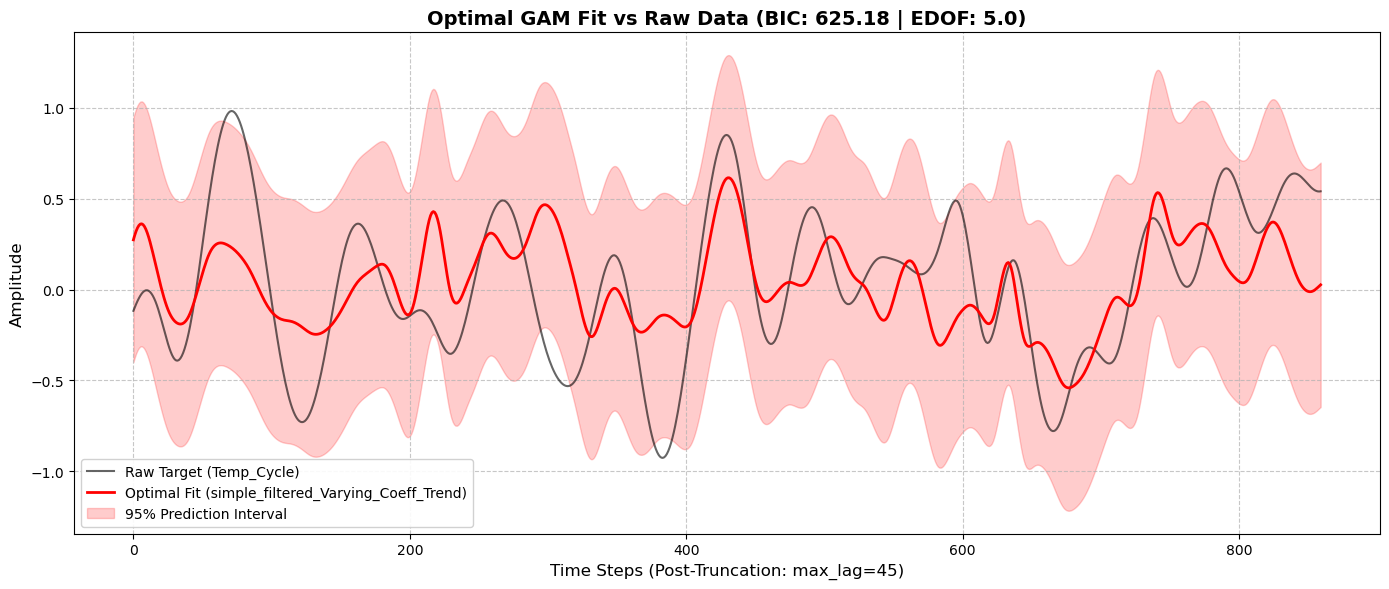


EXACT MODEL COEFFICIENTS (BASIS FUNCTION WEIGHTS)
Term 0 -> spline_term:
 [-1.86235121 -1.32399159]

Term 1 -> spline_term:
 [0.42786231 0.96415234]

Intercept:
 0.033779


Generating component evolution plots...


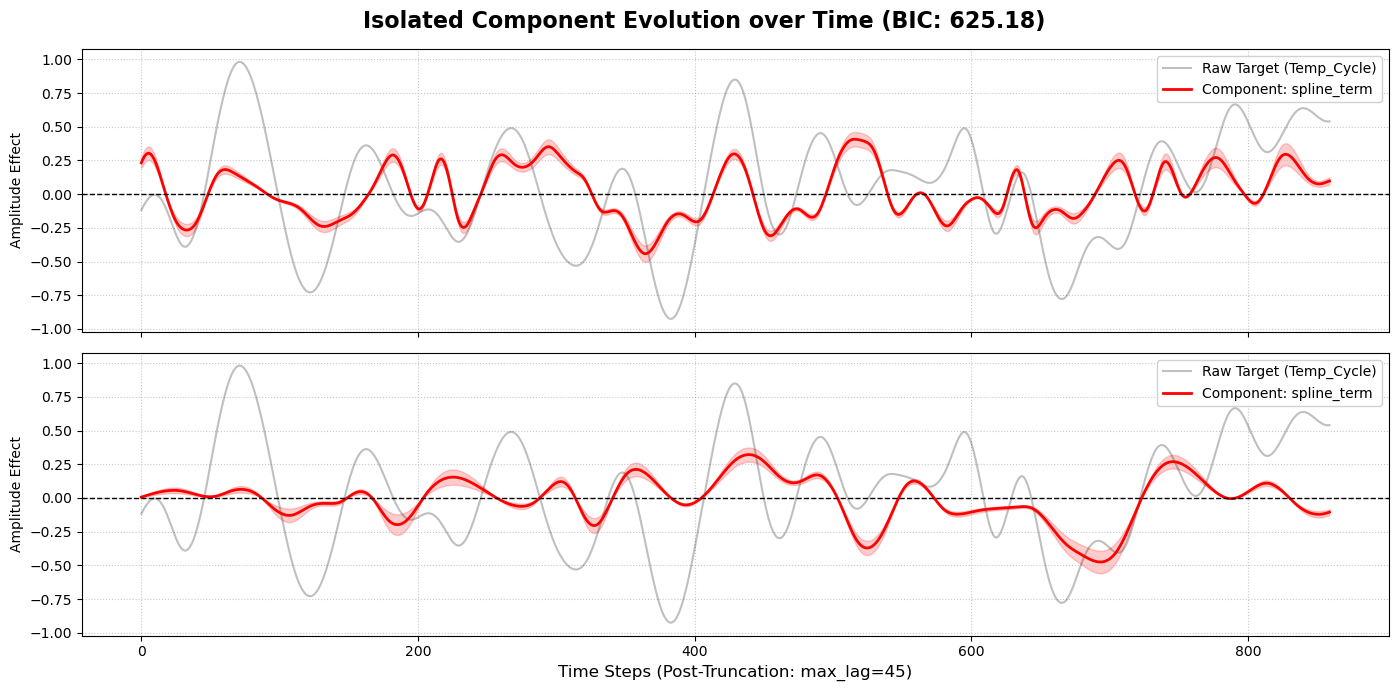


Generating static spline shape visualizations...


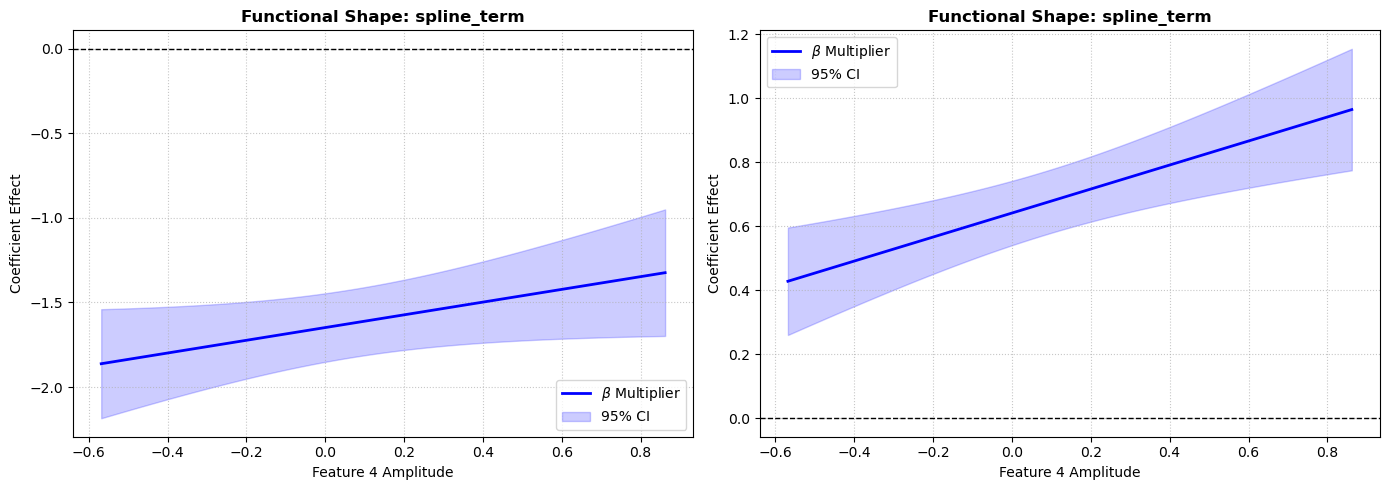

In [233]:
import pandas as pd
import numpy as np
import itertools
from pygam import LinearGAM, l, s, te
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. PARAMETERS AND LAG GRID DEFINITION
# ==============================================================================
lag_steps = [45] 
lag_combinations = list(itertools.product(lag_steps, repeat=4))
max_lag = max(lag_steps)

print(f"Total lag combinations to test: {len(lag_combinations)}")
print(f"Aligning all matrices to universal max lag limit: {max_lag} months...")

# Extract pure raw vectors
nao_raw = df_gam_filtered['NAO_Cycle'].values
ea_raw = df_gam_filtered['EA_Cycle'].values
sca_raw = df_gam_filtered['SCA_Cycle'].values
amo_raw = df_gam_filtered['AMO_Cycle'].values
y_raw = df_gam_filtered['Temp_Cycle'].values
trend_raw = df_gam_filtered['Global_Warming'].values
direct_nao = df_gam_filtered['NAO_Cycle'].values

# Stationary targets
y_base = y_raw[max_lag:]
trend_base = trend_raw[max_lag:]
direct_nao_base = direct_nao[max_lag:]
n_samples = len(y_base)

# ==============================================================================
# 2. ARCHITECTURE DEFINITIONS
# ==============================================================================
# We define a dictionary of formulations to test exhaustively.
# Spline degrees and basis functions are kept minimal to enforce simplicity.


# Variable 0 (NAO): Gentle monotonic curve -> Reduce to 4 splines
nao_mod = s(4, by=0, n_splines=4)

# Variable 1 (EA): Phase inversion curve -> Reduce to 4 splines
ea_mod = s(4, by=1, n_splines=4)

# Variable 2 (SCA): U-Shape -> Keep 5 splines to allow quadratic curve
sca_mod = s(4, by=2, n_splines=5)

# Variable 3 (AMO): Perfect straight line -> Force linear spline order
amo_mod = s(4, by=3, n_splines=4)


physics_informed_formulation = nao_mod + ea_mod + sca_mod + amo_mod


# 2. VCs constrained to absolute minimum splines
nao_mod_2 = s(4, by=5, n_splines=4)
nao_mod_2_s = s(4, by=5, spline_order=1, n_splines=2)
amo_mod_s = s(4, by=3, spline_order=1,n_splines=2)

filtered_formulation = nao_mod + amo_mod + nao_mod_2

simple_filtered_formulation = amo_mod_s + nao_mod_2_s
# Combine into the final optimized formulation
physics_informed_formulation_2 = nao_mod + ea_mod_2 + sca_mod_2 + amo_mod_2
formulations = {
#"Ebis_Varying_Coeff_Trend":  physics_informed_formulation,
#"Ebis_Varying_Coeff_Trend":  physics_informed_formulation,
"simple_filtered_Varying_Coeff_Trend":  simple_filtered_formulation
}

# ==============================================================================
# 3. EXHAUSTIVE GRID SEARCH EXECUTION
# ==============================================================================
results = []
total_tests = len(lag_combinations) * len(formulations)
current_test = 0

print("-" * 60)
print(f"Executing Multi-Architecture Global Lag Test ({total_tests} total fits)...")

for nao_lag, ea_lag, sca_lag, amo_lag in lag_combinations:
    
    # Shift variables
    nao_shifted = pd.Series(nao_raw).shift(nao_lag).values[max_lag:]
    ea_shifted  = pd.Series(ea_raw).shift(ea_lag).values[max_lag:]
    sca_shifted = pd.Series(sca_raw).shift(sca_lag).values[max_lag:]
    amo_shifted = pd.Series(amo_raw).shift(amo_lag).values[max_lag:]
    
    X_matrix = np.column_stack((nao_shifted, ea_shifted, sca_shifted, amo_shifted, trend_base, direct_nao_base))
        
    for form_name, formulation in formulations.items():
        current_test += 1
        
        try:
            model = LinearGAM(formulation)
            model.gridsearch(X_matrix, y_base, progress=False)
            
            aic = model.statistics_['AIC']
            edof = model.statistics_['edof']
            bic = aic + edof * (np.log(n_samples) - 2)
            
            results.append({
                "Model_Architecture": form_name,
                "NAO_Lag": nao_lag,
                "EA_Lag": ea_lag,
                "SCA_Lag": sca_lag,
                "AMO_Lag": amo_lag,
                "AIC": round(aic, 2),
                "BIC": round(bic, 2),
                "Pseudo_R2": round(model.statistics_['pseudo_r2']['explained_deviance'], 4),
                "EDOF": round(edof, 2)
            })
            
            if current_test % 100 == 0 or current_test == total_tests:
                current_best = min([r['BIC'] for r in results])
                print(f"[{current_test}/{total_tests}] Processed. Current Best BIC: {current_best}")
                
        except Exception as e:
            print(f"Failed on {form_name} with lag {nao_lag, ea_lag, sca_lag, amo_lag}: {e}")

# ==============================================================================
# 4. DIAGNOSTICS AND RANKING
# ==============================================================================
if not results:
    raise ValueError("No configurations were successfully processed. Check data alignment.")

df_results = pd.DataFrame(results)
df_ranked = df_results.sort_values(by="BIC", ascending=True).reset_index(drop=True)

print("\n" + "="*110)
print("EXHAUSTIVE ARCHITECTURE & LAG RANKING (TOP 15 CONFIGURATIONS)")
print("="*110)
print(df_ranked.head(15).to_string(index=False))

# ==============================================================================
# 5. VISUALIZATION OF THE OPTIMAL MODEL
# ==============================================================================
# Extract the absolute best configuration
best_config = df_ranked.iloc[0]
best_form_name = best_config['Model_Architecture']
best_nao_lag = int(best_config['NAO_Lag'])
best_ea_lag = int(best_config['EA_Lag'])
best_sca_lag = int(best_config['SCA_Lag'])
best_amo_lag = int(best_config['AMO_Lag'])

print(f"\nReconstructing: {best_form_name} with lags: NAO({best_nao_lag}), EA({best_ea_lag}), SCA({best_sca_lag}), AMO({best_amo_lag})")

# Re-shift the variables
best_nao_shifted = pd.Series(nao_raw).shift(best_nao_lag).values[max_lag:]
best_ea_shifted  = pd.Series(ea_raw).shift(best_ea_lag).values[max_lag:]
best_sca_shifted = pd.Series(sca_raw).shift(best_sca_lag).values[max_lag:]
best_amo_shifted = pd.Series(amo_raw).shift(best_amo_lag).values[max_lag:]

X_best = np.column_stack((best_nao_shifted, best_ea_shifted, best_sca_shifted, best_amo_shifted, trend_base, direct_nao_base))

# Fit the optimal GAM
best_formulation = formulations[best_form_name]
best_model = LinearGAM(best_formulation)
best_model.fit(X_best, y_base)

y_pred = best_model.predict(X_best)
y_intervals = best_model.prediction_intervals(X_best, width=0.95)

plt.figure(figsize=(14, 6))
time_steps = np.arange(len(y_base))

plt.plot(time_steps, y_base, label='Raw Target (Temp_Cycle)', color='black', alpha=0.6, linewidth=1.5)
plt.plot(time_steps, y_pred, label=f'Optimal Fit ({best_form_name})', color='red', linewidth=2)
plt.fill_between(time_steps, y_intervals[:, 0], y_intervals[:, 1], color='red', alpha=0.2, label='95% Prediction Interval')

plt.title(f'Optimal GAM Fit vs Raw Data (BIC: {best_config["BIC"]} | EDOF: {best_config["EDOF"]})', fontsize=14, fontweight='bold')
plt.xlabel(f'Time Steps (Post-Truncation: max_lag={max_lag})', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend(loc='best', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()
# ==============================================================================
# 6. EXACT COEFFICIENT EXTRACTION
# ==============================================================================
print("\n" + "="*85)
print("EXACT MODEL COEFFICIENTS (BASIS FUNCTION WEIGHTS)")
print("="*85)

# The total coefficient array
raw_coefs = best_model.coef_

start_idx = 0
for i, term in enumerate(best_model.terms):
    # Determine the number of coefficients for the current term
    n_coefs = term.n_coefs
    end_idx = start_idx + n_coefs
    
    # Slice the raw coefficient array
    term_coefs = raw_coefs[start_idx:end_idx]
    
    if term.isintercept:
        print(f"Intercept:\n {term_coefs[0]:.6f}\n")
    else:
        # Format the term representation for readability
        term_str = str(term).replace('\n', '').strip()
        print(f"Term {i} -> {term_str}:")
        print(f" {term_coefs}\n")
        
    start_idx = end_idx


# ==============================================================================
# 7. TEMPORAL EVOLUTION OF INDIVIDUAL COMPONENTS (DYNAMIC)
# ==============================================================================
print("\nGenerating component evolution plots...")

# Dynamically extract all valid (non-intercept) terms from the model
valid_terms = [(i, term) for i, term in enumerate(best_model.terms) if not term.isintercept]
n_terms = len(valid_terms)

if n_terms == 0:
    raise ValueError("The model contains no valid splines to plot.")

# Initialize dynamic subplots based on the exact number of active components
fig, axes = plt.subplots(n_terms, 1, figsize=(14, 3.5 * n_terms), sharex=True)

# Ensure axes is iterable even if there is only 1 term left in the model
if n_terms == 1:
    axes = [axes]

time_steps = np.arange(len(y_base))

for ax, (term_idx, term) in zip(axes, valid_terms):
    
    # Generate a dynamic title based on the underlying spline formula
    term_str = str(term).replace('\n', '').strip()
    title = f"Component: {term_str}"
    
    # 1. Extract the isolated temporal contribution
    component_evolution, confi_intervals = best_model.partial_dependence(term=term_idx, X=X_best, width=0.95)
    
    # 2. Plot Raw Target (Background reference)
    ax.plot(time_steps, y_base, color='black', alpha=0.25, linewidth=1.5, label='Raw Target (Temp_Cycle)')
    
    # 3. Plot Component Evolution
    ax.plot(time_steps, component_evolution, color='red', linewidth=2, label=title)
    
    # 4. Plot 95% Confidence Interval
    ax.fill_between(time_steps, confi_intervals[:, 0], confi_intervals[:, 1], color='red', alpha=0.2)
    
    # Formatting
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel('Amplitude Effect', fontsize=10)
    ax.legend(loc='upper right', framealpha=0.9)
    ax.grid(True, linestyle=':', alpha=0.7)

# Global formatting
plt.suptitle(f'Isolated Component Evolution over Time (BIC: {best_config["BIC"]})', fontsize=16, fontweight='bold', y=0.98)
plt.xlabel(f'Time Steps (Post-Truncation: max_lag={max_lag})', fontsize=12)
plt.tight_layout()

# Execute plot
plt.show()

# ==============================================================================
# 8. SPLINE SHAPE VISUALIZATION (PARTIAL DEPENDENCE CURVES)
# ==============================================================================
print("\nGenerating static spline shape visualizations...")

# Dynamically extract all valid (non-intercept) terms from the model
valid_terms = [(i, term) for i, term in enumerate(best_model.terms) if not term.isintercept]
n_terms = len(valid_terms)

if n_terms == 0:
    raise ValueError("The model contains no valid splines to plot.")

# Set up a dynamic grid for the subplots (2 columns, auto-calculating rows)
cols = 2
rows = int(np.ceil(n_terms / cols))
fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))

# Flatten axes array for easy iteration, handling cases where there's only 1 row or 1 plot
axes = np.atleast_1d(axes).flatten()

for idx, (term_idx, term) in enumerate(valid_terms):
    ax = axes[idx]
    
    # 1. Generate a synthetic grid of 100 points strictly for this term
    XX = best_model.generate_X_grid(term=term_idx)
    
    # 2. Extract the partial dependence (beta multiplier) and confidence intervals
    pdep, confi = best_model.partial_dependence(term=term_idx, X=XX, width=0.95)
    
    # 3. Isolate the X-axis values. 
    # term.feature gives the integer column index of the primary variable in X_matrix (e.g., 4 for Trend)
    feature_idx = term.feature
    x_grid = XX[:, feature_idx]
    
    term_str = str(term).replace('\n', '').strip()
    
    # 4. Plotting
    ax.plot(x_grid, pdep, color='blue', linewidth=2, label=r'$\beta$ Multiplier')
    ax.fill_between(x_grid, confi[:, 0], confi[:, 1], color='blue', alpha=0.2, label='95% CI')
    
    # Add zero-line to easily identify phase inversions
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    
    ax.set_title(f'Functional Shape: {term_str}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'Feature {feature_idx} Amplitude', fontsize=10)
    ax.set_ylabel('Coefficient Effect', fontsize=10)
    ax.legend(loc='best')
    ax.grid(True, linestyle=':', alpha=0.7)

# Remove any empty subplots if n_terms is odd
for idx in range(n_terms, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

In [232]:
import pandas as pd
import numpy as np
import itertools
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error, r2_score

def grid_search_lags_cv(
    df: pd.DataFrame, 
    target_col: str, 
    lag_grid: dict, 
    static_features: list, 
    model_factory: callable, 
    n_splits: int = 5
) -> pd.DataFrame:
    """
    Evaluates different lag combinations for time-series features using K-Fold CV.
    
    Parameters:
    df (pd.DataFrame): The dataset containing all features and the target.
    target_col (str): The name of the target variable.
    lag_grid (dict): Dictionary mapping feature names to a list of integer lags to test.
                     e.g., {'NAO': [0, 60], 'EA': [160]}
    static_features (list): Features that should NOT be lagged (e.g., background trend).
    model_factory (callable): A function/lambda that returns a fresh, un-fitted model instance.
    n_splits (int): Number of K-Fold splits.
    
    Returns:
    pd.DataFrame: Ranked results sorted by Mean Out-of-Fold RMSE.
    """
    
    # 1. Determine the universal truncation limit to keep sample size constant
    max_lag_overall = max([max(lags) for lags in lag_grid.values()])
    print(f"Universal max lag limit set to: {max_lag_overall} steps.")
    
    # 2. Extract stationary base targets and static features
    y_base = df[target_col].values[max_lag_overall:]
    static_matrix = df[static_features].values[max_lag_overall:]
    
    # 3. Generate all permutations from the lag grid
    feature_names = list(lag_grid.keys())
    lag_combinations = list(itertools.product(*lag_grid.values()))
    
    # Initialize Time-Series safe K-Fold (no shuffling)
    kf = TimeSeriesSplit(n_splits=n_splits, test_size=len(y_base)//10)
    results = []
    
    total_tests = len(lag_combinations)
    print(f"Executing K-Fold CV across {total_tests} configurations...\n")
    
    # 4. Exhaustive Grid Search
    for idx, current_lags in enumerate(lag_combinations, 1):
        
        # Build the dynamic shifted feature matrix for this combination
        shifted_features = []
        for feature, lag in zip(feature_names, current_lags):
            shifted_col = df[feature].shift(lag).values[max_lag_overall:]
            shifted_features.append(shifted_col)
            
        # Combine shifted features with static features
        X_matrix = np.column_stack([*shifted_features, static_matrix])
        
        # K-Fold CV Loop
        fold_rmse = []
        fold_r2 = []
        
        for train_idx, test_idx in kf.split(X_matrix):
            X_train, X_test = X_matrix[train_idx], X_matrix[test_idx]
            y_train, y_test = y_base[train_idx], y_base[test_idx]
            
            # Instantiate a fresh model to prevent state leakage
            model = model_factory()
            
            try:
                # Fit and predict
                model.fit(X_train, y_train)
                preds = model.predict(X_test)
                
                # Calculate Out-of-Fold metrics
                fold_rmse.append(root_mean_squared_error(y_test, preds))
                fold_r2.append(r2_score(y_test, preds))
                
            except Exception as e:
                print(f"Fold failed for lags {current_lags}: {e}")
                fold_rmse.append(np.nan)
                fold_r2.append(np.nan)
        
        # Aggregate Results
        res_dict = {f"{feat}_Lag": lag for feat, lag in zip(feature_names, current_lags)}
        res_dict.update({
            "Mean_CV_RMSE": np.nanmean(fold_rmse),
            "Std_CV_RMSE": np.nanstd(fold_rmse),
            "Mean_CV_R2": np.nanmean(fold_r2)
        })
        results.append(res_dict)
        
        if idx % 20 == 0 or idx == total_tests:
            print(f"[{idx}/{total_tests}] Processed.")
            
    # 5. Format and Rank Output
    df_results = pd.DataFrame(results)
    df_ranked = df_results.sort_values(by="Mean_CV_RMSE", ascending=True).reset_index(drop=True)
    
    return df_ranked


# Define the lag search space
lag_grid_params = {
    'NAO_Cycle': [0],
    'EA_Cycle': [160],
    'SCA_Cycle': [90],
    'AMO_Cycle': [45]
}

# Define features that do not shift
static_cols = ['Global_Warming']

# Define the optimal Varying Coefficient architecture
optimal_formulation = core_formulation

# Create a factory function for the model
gam_factory = lambda: LinearGAM(optimal_formulation, lam=20.0)

# Run the CV Grid Search
ranked_results = grid_search_lags_cv(
    df=df_gam_filtered,
    target_col='Temp_Cycle',
    lag_grid=lag_grid_params,
    static_features=static_cols,
    model_factory=gam_factory,
    n_splits=10
)

print(ranked_results.head(10).to_string(index=False))

Universal max lag limit set to: 160 steps.
Executing K-Fold CV across 1 configurations...

[1/1] Processed.
 NAO_Cycle_Lag  EA_Cycle_Lag  SCA_Cycle_Lag  AMO_Cycle_Lag  Mean_CV_RMSE  Std_CV_RMSE  Mean_CV_R2
             0           160             90             45      0.514068     0.169372   -5.524057


In [ ]:
# 1. Feature Extraction and Alignment
max_lag_overall = 45

# Instantaneous atmospheric forcing
nao_shifted = df_gam_filtered['NAO_Cycle'].shift(0).values[max_lag_overall:]

# 3.75-year delayed oceanic forcing
amo_shifted = df_gam_filtered['AMO_Cycle'].shift(45).values[max_lag_overall:]

y_base = df_gam_filtered['Temp_Cycle'].values[max_lag_overall:]

X_matrix_core = np.column_stack((nao_shifted, amo_shifted))

# 2. Lean Formulation
# Variable 0: NAO (Lag 0)
# Variable 1: AMO (Lag 45)
# Variable 2: Global Warming Trend


linear_formulation =  (l(1) + l(0))
core_formulation = (
     # Stiff Background Trend
    s(2, by=0, spline_order=1, n_splines=2) + # NAO VC (Modulated by Trend)
    s(2, by=1, spline_order=1, n_splines=2)   # AMO VC (Modulated by Trend)
)
core_formulation_2 = (
     # Stiff Background Trend
    s(1, by=0, spline_order=1, n_splines=2) + # NAO VC (Modulated by AMO)
    s(2, by=1, spline_order=1, n_splines=2) + # AMO VC (Modulated by Trend)
    s(2, by=0, spline_order=1, n_splines=2) # AO VC (Modulated by Trend)
)



tensor_formulation = (
     te(0, 1, n_splines=[4, 4])
)

tensor_formulation_2 = (
     te(0, 1, spline_order=1, n_splines=[2, 2])
)

In [273]:
df_new = pd.DataFrame(data={"NAO" : nao_shifted, "AMO" : amo_shifted, "trend" : df_gam_filtered['Global_Warming'][45:],'Temp_Cycle' : df_gam_filtered['Temp_Cycle'][45:]})

optimal_formulation = core_formulation_2

# Create a factory function for the model
gam_factory = lambda: LinearGAM(optimal_formulation, lam=20.0)

ranked_results = grid_search_lags_cv(
    df=df_new,
    target_col='Temp_Cycle',
    lag_grid={"NAO": [0]},
    static_features=["AMO", 'trend'],
    model_factory=gam_factory,
    n_splits=5
)

print(ranked_results.head(10).to_string(index=False))

Universal max lag limit set to: 0 steps.
Executing K-Fold CV across 1 configurations...

[1/1] Processed.
 NAO_Lag  Mean_CV_RMSE  Std_CV_RMSE  Mean_CV_R2
       0      0.328596     0.091075   -3.786199


https://iopscience.iop.org/article/10.1088/1748-9326/aba925


Generating the 3D Bilinear Interaction Surface...


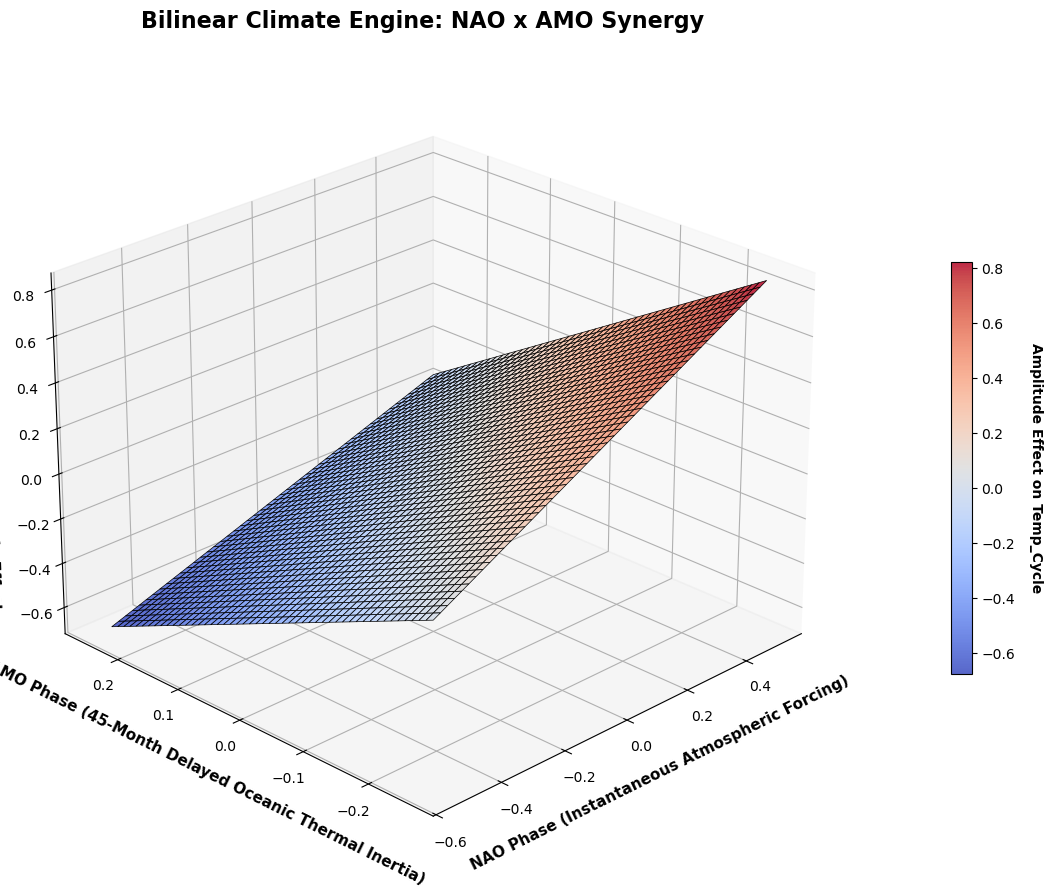

In [265]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from pygam import LinearGAM, te

# ==============================================================================
# 1. FIT THE OPTIMAL BILINEAR TENSOR MODEL
# ==============================================================================
# Assuming X_matrix_core is: Col 0 -> NAO (Lag 0), Col 1 -> AMO (Lag 45)
# We enforce spline_order=1 and n_splines=2 to create a strict bilinear surface
optimal_tensor_formulation = te(0, 1, spline_order=1, n_splines=[2, 2])

# Fit with your established penalization
final_model = LinearGAM(optimal_tensor_formulation, lam=50.0)
final_model.fit(X_matrix_core, y_base)

# ==============================================================================
# 2. FINAL VISUALIZATION: THE 3D CLIMATE INTERACTION ENGINE
# ==============================================================================
print("\nGenerating the 3D Bilinear Interaction Surface...")

# A. Generate a dense 50x50 coordinate grid across the physical ranges of NAO and AMO
XX_tensor = final_model.generate_X_grid(term=0, meshgrid=True, n=50)

# B. Extract the predicted temperature anomaly (Z-axis) across this grid
# FIX: Remove the tuple unpacking (`, _`). It returns a single 2D array.
Z_surface = final_model.partial_dependence(term=0, X=XX_tensor, meshgrid=True)

# C. Isolate the spatial axes directly from the tensor list
# FIX: Extract the 2D meshgrids directly
X_nao = XX_tensor[0]  # NAO Phase physical values
Y_amo = XX_tensor[1]  # AMO Phase physical values

# D. Construct the 3D Projection
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(X_nao, Y_amo, Z_surface, 
                       cmap='coolwarm', 
                       edgecolor='black', 
                       linewidth=0.5, 
                       alpha=0.85)

# Formatting and Physical Labels
ax.set_title('Bilinear Climate Engine: NAO x AMO Synergy', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('\nNAO Phase (Instantaneous Atmospheric Forcing)', fontsize=11, fontweight='bold')
ax.set_ylabel('\nAMO Phase (45-Month Delayed Oceanic Thermal Inertia)', fontsize=11, fontweight='bold')
ax.set_zlabel('\nTarget Temperature Anomaly Effect', fontsize=11, fontweight='bold')

# Quantifiable Color Bar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label('Amplitude Effect on Temp_Cycle', rotation=270, labelpad=20, fontweight='bold')

# Optimal viewing angle to expose the structural "twist" of the interaction
ax.view_init(elev=25, azim=225)

plt.tight_layout()
plt.show()

In [216]:
import numpy as np
baseline_std = np.std(df_gam_filtered['Temp_Cycle'].values[max_lag_overall:])
print(f"Global Target Standard Deviation: {baseline_std:.6f}")

Global Target Standard Deviation: 0.412763


In [184]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, root_mean_squared_error
import numpy as np

# 1. Initialize TimeSeriesSplit (Matching your previous setup)
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# 2. Initialize Ridge Regression (Alpha is the L2 penalty, similar to GAM's lam)
ridge_model = Ridge(alpha=100.0)

fold_rmse = []
fold_r2 = []

print("-" * 50)
print("PURE LINEAR RIDGE REGRESSION CV (THE FINAL BASELINE)")
print("-" * 50)

for train_idx, test_idx in tscv.split(X_matrix_core):
    X_train, X_test = X_matrix_core[train_idx], X_matrix_core[test_idx]
    y_train, y_test = y_base[train_idx], y_base[test_idx]
    
    # Fit and Predict
    ridge_model.fit(X_train, y_train)
    preds = ridge_model.predict(X_test)
    
    # Calculate Metrics
    rmse = root_mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    fold_rmse.append(rmse)
    fold_r2.append(r2)
    
    print(f"Fold R2: {r2:8.4f} | RMSE: {rmse:8.4f}")

print("-" * 50)
print(f"Mean CV RMSE: {np.mean(fold_rmse):.4f}")
print(f"Mean CV R2:   {np.mean(fold_r2):.4f}")

--------------------------------------------------
PURE LINEAR RIDGE REGRESSION CV (THE FINAL BASELINE)
--------------------------------------------------
Fold R2:  -0.0557 | RMSE:   0.2641
Fold R2:  -0.2706 | RMSE:   0.5198
Fold R2:  -0.5566 | RMSE:   0.3111
Fold R2:  -0.2784 | RMSE:   0.4028
Fold R2:  -3.7273 | RMSE:   0.4708
--------------------------------------------------
Mean CV RMSE: 0.3937
Mean CV R2:   -0.9777


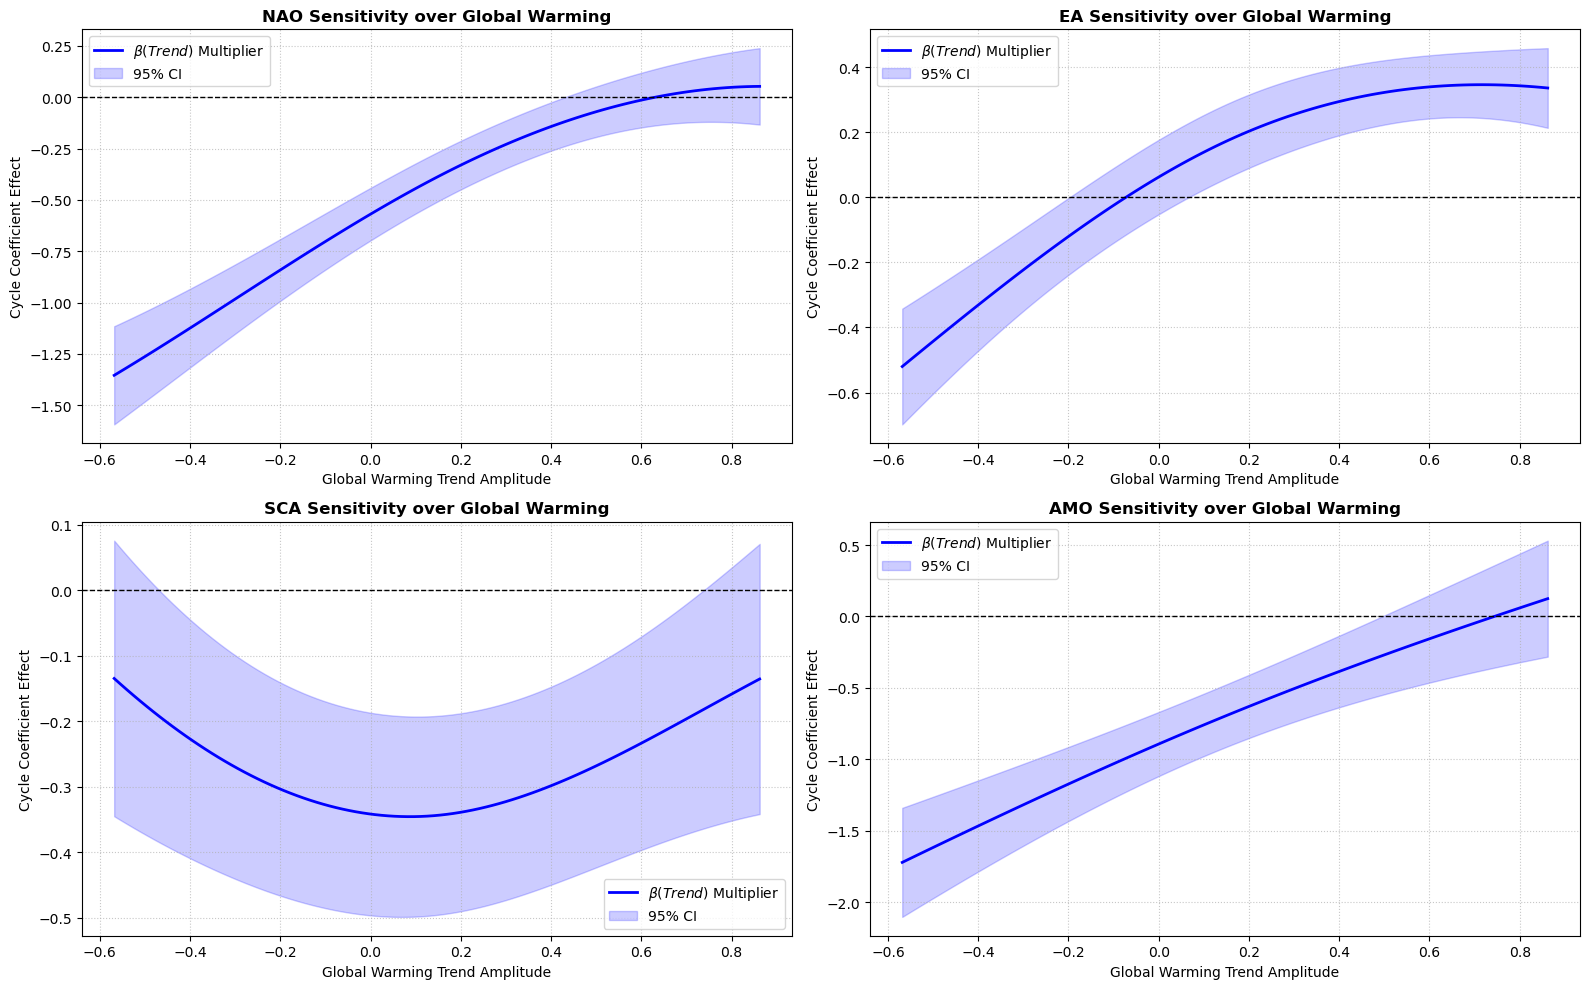

In [127]:
import matplotlib.pyplot as plt

# Define the exact term indices based on the architecture:
# l(0) [0], l(1) [1], l(2) [2], l(3) [3], s(4) [4]
# s(4, by=0) [5], s(4, by=1) [6], s(4, by=2) [7], s(4, by=3) [8]

interaction_terms = {
    'NAO Sensitivity': 5,
    'EA Sensitivity': 6,
    'SCA Sensitivity': 7,
    'AMO Sensitivity': 8
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (title, term_idx) in enumerate(interaction_terms.items()):
    ax = axes[idx]
    
    # Generate a dense grid strictly for the Trend variable (feature index 4)
    XX = best_model.generate_X_grid(term=term_idx)
    
    # Extract the partial dependence (the beta multiplier) and confidence intervals
    pdep, confi = best_model.partial_dependence(term=term_idx, X=XX, width=0.95)
    
    # XX[:, 4] isolates the Global Warming Trend values generated for the grid
    trend_grid = XX[:, 4]
    
    # Plotting
    ax.plot(trend_grid, pdep, color='blue', linewidth=2, label=r'$\beta(Trend)$ Multiplier')
    ax.fill_between(trend_grid, confi[:, 0], confi[:, 1], color='blue', alpha=0.2, label='95% CI')
    
    # Add a horizontal zero-line to identify phase inversions
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    
    ax.set_title(f'{title} over Global Warming', fontsize=12, fontweight='bold')
    ax.set_xlabel('Global Warming Trend Amplitude', fontsize=10)
    ax.set_ylabel(f'Cycle Coefficient Effect', fontsize=10)
    ax.legend(loc='best')
    ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [107]:
import pandas as pd
from typing import List, Dict, Tuple

def engineer_time_series_features(
    df: pd.DataFrame, 
    lag_config: Dict[str, List[int]], 
    interaction_pairs: List[Tuple[str, str, str]]
) -> pd.DataFrame:
    """
    Expands a dataframe with specified lags and cross-feature interactions.
    
    Parameters:
    df (pd.DataFrame): Time-indexed dataframe.
    lag_config (Dict[str, List[int]]): Mapping of column names to lists of integer lags.
                                       e.g., {'price': [1, 2, 3], 'volume': [1, 5]}
    interaction_pairs (List[Tuple[str, str, str]]): List of tuples defining the interactions
                                                    (col_A, col_B, operation).
                                                    Valid operations: 'mul', 'add', 'div'.
    
    Returns:
    pd.DataFrame: DataFrame containing the original and newly engineered features.
    """
    df_expanded = df.copy()
    
    # 1. Generate Multiple Lags
    for feature, lags in lag_config.items():
        if feature not in df.columns:
            raise KeyError(f"Feature '{feature}' not found in DataFrame.")
            
        for lag in lags:
            lagged_col_name = f"{feature}_lag_{lag}"
            df_expanded[lagged_col_name] = df_expanded[feature].shift(lag)
            
    # 2. Generate Non-Independent Relations
    for col1, col2, op in interaction_pairs:
        if col1 not in df_expanded.columns or col2 not in df_expanded.columns:
            raise KeyError(f"Interaction features '{col1}' or '{col2}' not found.")
            
        interaction_name = f"{col1}_{op}_{col2}"
        
        if op == 'mul':
            df_expanded[interaction_name] = df_expanded[col1] * df_expanded[col2]
        elif op == 'add':
            df_expanded[interaction_name] = df_expanded[col1] + df_expanded[col2]
        elif op == 'div':
            # Replaces 0 with NaN to prevent ZeroDivisionError propagation into inf
            df_expanded[interaction_name] = df_expanded[col1] / df_expanded[col2].replace(0, pd.NA)
        else:
            raise ValueError(f"Unsupported operation: '{op}'")
            
    return df_expanded

# Example execution parameters:
# lag_config = {
#     'feature_A': [1, 2, 4],
#     'feature_B': [1, 12]
# }
# interaction_pairs = [
#     ('feature_A_lag_1', 'feature_B_lag_1', 'mul'), 
#     ('feature_A_lag_4', 'feature_A', 'div')       
# ]

In [98]:
import pandas as pd

# ==============================================================================
# 1. APPLYING THE TEMPORAL SHIFTS (LAGS)
# ==============================================================================
# We create a copy to avoid altering the original extracted cycles
df_predictive = df_gam_filtered.copy()

# The Atmospheric predictors operate concurrently (Lag 0), so we leave them alone.
# df_predictive['NAO_Cycle'] = df_gam_filtered['NAO_Cycle']
# df_predictive['EA_Cycle']  = df_gam_filtered['EA_Cycle']
# df_predictive['SCA_Cycle'] = df_gam_filtered['SCA_Cycle']

# The Oceanic predictor must be shifted FORWARD to align its past with the present target.
# A shift of +160 means the AMO value from row 0 is pushed down to row 160.


# ==============================================================================
# 2. MATRIX ALIGNMENT
# ==============================================================================
# Shifting arrays creates missing data (NaNs) at the beginning of the dataset.
# The first 160 months of the target variable no longer have a corresponding AMO history.
# We must drop these rows to ensure the GAM receives a complete, dense matrix.
df_predictive = df_predictive.dropna()

# ==============================================================================
# 3. DEFINING THE FINAL FEATURE TENSOR
# ==============================================================================
# Re-extract the aligned arrays
y_final = df_predictive['Temp_Cycle'].values

# The feature matrix X is now perfectly phase-aligned based on physical causality
X_final = df_predictive[['NAO_Cycle', 'EA_Cycle', 'SCA_Cycle', 'AMO_Cycle', 'Global_Warming']].values

In [99]:
import pandas as pd
from pygam import LinearGAM, l, s, te

# ==============================================================================
# 1. MATRIX DEFINITION (CONCURRENT STRICT)
# ==============================================================================
# IMPORTANT: Ensure X_final is an np.column_stack of all 5 arrays
X_concurrent = X_final
y_concurrent = y_final

# Index 0: NAO_Cycle (Concurrent)
# Index 1: EA_Cycle (Concurrent)
# Index 2: SCA_Cycle (Concurrent)
# Index 3: AMO_Cycle (Lagged or Concurrent based on your X_final construction)
# Index 4: Background_Trend (CEEMDAN Residual)

# ==============================================================================
# 2. ARCHITECTURE DEFINITIONS
# ==============================================================================
architectures = {
    # Baselines + Background Trend
    "1. Strictly Linear (Additive)": l(0) + l(1) + l(2) + l(3) + s(4, spline_order=2),
    "2. Independent Splines (Non-Linear Additive)": s(0, spline_order=2) + s(1, spline_order=2) + s(2, spline_order=2) + s(3, spline_order=2) + s(4, spline_order=2),
    
    # 2-Way Atmospheric Interactions + Independent Ocean + Background Trend
    "3. Interaction: [NAO x EA] + Splines(SCA, AMO)": te(0, 1, n_splines=(2, 2), spline_order=1) + s(2, spline_order=2) + s(3, spline_order=2) + s(4, spline_order=2),
    "4. Interaction: [NAO x SCA] + Splines(EA, AMO)": te(0, 2, n_splines=(2, 2), spline_order=1) + s(1, spline_order=2) + s(3, spline_order=2) + s(4, spline_order=2),
    "5. Interaction: [EA x SCA] + Splines(NAO, AMO)": te(1, 2, n_splines=(2, 2), spline_order=1) + s(0, spline_order=2) + s(3, spline_order=2) + s(4, spline_order=2),
    
    # 3-Way Atmospheric Tensors + Independent Ocean + Background Trend
    "6. 3-Way Atmospheric Tensor + Linear AMO": te(0, 1, 2, n_splines=(2, 2, 2), spline_order=1) + l(3) + s(4, spline_order=2),
    "7. 3-Way Atmospheric Tensor + Spline AMO": te(0, 1, 2, n_splines=(2, 2, 2), spline_order=1) + s(3, spline_order=2) + s(4, spline_order=2),
    
    # Fully Coupled 4-Dimensional Interaction + Background Trend
    "8. Full 4-Way Tensor (Atmosphere x Ocean)": te(0, 1, 2, 3, n_splines=(2, 2, 2, 2), spline_order=1) + s(4, spline_order=2)
    
}
architectures2 = {
    # -------------------------------------------------------------------------
    # CONTROL: The baseline we established (Trend is purely an additive intercept)
    "1. CONTROL: 3D Atmosphere + Lagged Ocean + Additive Trend": 
        te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + l(3) + s(4, spline_order=2),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS A: The Trend only modulates the Ocean's heat release. 
    # The Atmosphere distributes it normally.
    "2. Trend x Ocean: [AMO x Trend] + 3D Atmosphere": 
        te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + te(3, 4, n_splines=(4, 4), spline_order=2),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS B: The Trend modulates the Atmosphere INDIVIDUALLY.
    # The pressure networks are independent of each other, but dependent on the warming era.
    "3. Trend x Isolated Atmosphere: [NAO x Trend] + [EA x Trend] + [SCA x Trend]": 
        te(0, 4, n_splines=(3, 3), spline_order=2) + te(1, 4, n_splines=(3, 3), spline_order=2) + te(2, 4, n_splines=(3, 3), spline_order=2) + l(3),

    # -------------------------------------------------------------------------
    # HYPOTHESIS C: The Trend modulates the specific 2-Way atmospheric couplings.
    "4. Trend x 2-Way Atmosphere: [NAO x EA x Trend] + Splines(SCA, AMO)": 
        te(0, 1, 4, n_splines=(2, 2, 2), spline_order=1) + s(2, spline_order=2) + l(3),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS D: The Trend modulates the ENTIRE 3D atmospheric boundary layer.
    # The tri-pole behaves fundamentally differently in a hotter world.
    "5. Trend x 3D Atmosphere: [NAO x EA x SCA x Trend] + Linear Ocean": 
        te(0, 1, 2, 4, n_splines=(2, 2, 2, 2), spline_order=1) + l(3),
        
    # -------------------------------------------------------------------------
    # HYPOTHESIS E: Total System Coupling (The absolute limit of PyGAM math).
    # Everything interacts with everything, shifting dynamically with global warming.
    "6. Fully Coupled 5D System: [Atmosphere x Ocean x Trend]": 
        te(0, 1, 2, 3, 4, n_splines=(2, 2, 2, 2, 2), spline_order=1)
}
# ==============================================================================
# 3. EXECUTION AND DIAGNOSTICS
# ==============================================================================
results = []

print(f"Executing Exhaustive Concurrent GAM Test on {len(X_concurrent)} rows with 5 Dimensions...")

for name, formulation in architectures2.items():
    try:
        model = LinearGAM(formulation)
        model.gridsearch(X_concurrent, y_concurrent, progress=False)
        
        results.append({
            "Architecture": name,
            "AIC": model.statistics_['AIC'],
            "GCV": model.statistics_['GCV'],
            "EDOF": model.statistics_['edof'],
            "Pseudo R-Squared": model.statistics_['pseudo_r2']['explained_deviance']
        })
    except Exception as e:
        results.append({
            "Architecture": name,
            "AIC": float('inf'),
            "GCV": float('inf'),
            "EDOF": 0,
            "Pseudo R-Squared": 0.0
        })
        print(f"Failed on {name}: {e}")

# ==============================================================================
# 4. OUTPUT
# ==============================================================================
df_results = pd.DataFrame(results).sort_values(by="AIC")

print("\n========================================================================================")
print("ARCHITECTURE PERFORMANCE RANKING (ANCHORED TREND)")
print("========================================================================================")
print(df_results.to_string(index=False))

Executing Exhaustive Concurrent GAM Test on 905 rows with 5 Dimensions...

ARCHITECTURE PERFORMANCE RANKING (ANCHORED TREND)
                                                                Architecture          AIC      GCV      EDOF  Pseudo R-Squared
                   1. CONTROL: 3D Atmosphere + Lagged Ocean + Additive Trend -3916.796446 0.000795 32.473415          0.985105
                    6. Fully Coupled 5D System: [Atmosphere x Ocean x Trend] -2011.096087 0.006525 31.999850          0.877537
3. Trend x Isolated Atmosphere: [NAO x Trend] + [EA x Trend] + [SCA x Trend] -1756.819022 0.008532 18.981026          0.833004
                             2. Trend x Ocean: [AMO x Trend] + 3D Atmosphere -1669.260027 0.009474 27.124123          0.819363
           5. Trend x 3D Atmosphere: [NAO x EA x SCA x Trend] + Linear Ocean -1405.021393 0.012562 16.937372          0.752538
         4. Trend x 2-Way Atmosphere: [NAO x EA x Trend] + Splines(SCA, AMO) -1195.462168 0.015962 25.239080     

In [87]:
import pandas as pd
from pygam import LinearGAM, l, s, te

# ==============================================================================
# 1. MATRIX DEFINITION
# ==============================================================================
# Index 0: NAO_Cycle 
# Index 1: EA_Cycle 
# Index 2: SCA_Cycle 
# Index 3: AMO_Lagged (160 Months)
# Index 4: Background_Trend (CEEMDAN Residual)

X_concurrent = X_final
y_concurrent = y_final

# ==============================================================================
# 2. TREND-DEPENDENT ARCHITECTURE DEFINITIONS
# ==============================================================================
architectures = {
    # -------------------------------------------------------------------------
    # CONTROL: The baseline we established (Trend is purely an additive intercept)
    "1. CONTROL: 3D Atmosphere + Lagged Ocean + Additive Trend": 
        te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + l(3) + s(4, spline_order=2),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS A: The Trend only modulates the Ocean's heat release. 
    # The Atmosphere distributes it normally.
    "2. Trend x Ocean: [AMO x Trend] + 3D Atmosphere": 
        te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + te(3, 4, n_splines=(4, 4), spline_order=2),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS B: The Trend modulates the Atmosphere INDIVIDUALLY.
    # The pressure networks are independent of each other, but dependent on the warming era.
    "3. Trend x Isolated Atmosphere: [NAO x Trend] + [EA x Trend] + [SCA x Trend]": 
        te(0, 4, n_splines=(3, 3), spline_order=2) + te(1, 4, n_splines=(3, 3), spline_order=2) + te(2, 4, n_splines=(3, 3), spline_order=2) + l(3),

    # -------------------------------------------------------------------------
    # HYPOTHESIS C: The Trend modulates the specific 2-Way atmospheric couplings.
    "4. Trend x 2-Way Atmosphere: [NAO x EA x Trend] + Splines(SCA, AMO)": 
        te(0, 1, 4, n_splines=(2, 2, 2), spline_order=1) + s(2, spline_order=2) + l(3),
    
    # -------------------------------------------------------------------------
    # HYPOTHESIS D: The Trend modulates the ENTIRE 3D atmospheric boundary layer.
    # The tri-pole behaves fundamentally differently in a hotter world.
    "5. Trend x 3D Atmosphere: [NAO x EA x SCA x Trend] + Linear Ocean": 
        te(0, 1, 2, 4, n_splines=(2, 2, 2, 2), spline_order=1) + l(3),
        
    # -------------------------------------------------------------------------
    # HYPOTHESIS E: Total System Coupling (The absolute limit of PyGAM math).
    # Everything interacts with everything, shifting dynamically with global warming.
    "6. Fully Coupled 5D System: [Atmosphere x Ocean x Trend]": 
        te(0, 1, 2, 3, 4, n_splines=(2, 2, 2, 2, 2), spline_order=1)
}

# ==============================================================================
# 3. EXECUTION AND DIAGNOSTICS (Using 5-Fold Walk-Forward Validation)
# ==============================================================================
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score

tscv = TimeSeriesSplit(n_splits=5)
fold_metrics = []

print(f"Executing Walk-Forward Validation on Trend-Dependent Architectures...")

for name, formulation in architectures.items():
    print(f"Testing: {name}")
    
    for fold, (train_index, test_index) in enumerate(tscv.split(X_concurrent), 1):
        X_train, X_test = X_concurrent[train_index], X_concurrent[test_index]
        y_train, y_test = y_concurrent[train_index], y_concurrent[test_index]

        model = LinearGAM(formulation)
        
        try:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            r2 = r2_score(y_test, y_pred)
            
            fold_metrics.append({
                'Architecture': name,
                'Fold': fold,
                'R2': r2
            })
        except Exception as e:
            fold_metrics.append({
                'Architecture': name,
                'Fold': fold,
                'R2': np.nan
            })

df_folds = pd.DataFrame(fold_metrics)
df_summary = df_folds.groupby('Architecture')['R2'].mean().sort_values(ascending=False).reset_index()

print("\n===========================================================")
print("TREND-DEPENDENT OUT-OF-SAMPLE STABILITY RANKING (5 FOLDS)")
print("===========================================================")
print(df_summary.to_string(index=False))

Executing Walk-Forward Validation on Trend-Dependent Architectures...
Testing: 1. CONTROL: 3D Atmosphere + Lagged Ocean + Additive Trend
Testing: 2. Trend x Ocean: [AMO x Trend] + 3D Atmosphere
Testing: 3. Trend x Isolated Atmosphere: [NAO x Trend] + [EA x Trend] + [SCA x Trend]
Testing: 4. Trend x 2-Way Atmosphere: [NAO x EA x Trend] + Splines(SCA, AMO)
Testing: 5. Trend x 3D Atmosphere: [NAO x EA x SCA x Trend] + Linear Ocean
Testing: 6. Fully Coupled 5D System: [Atmosphere x Ocean x Trend]

TREND-DEPENDENT OUT-OF-SAMPLE STABILITY RANKING (5 FOLDS)
                                                                Architecture           R2
                             2. Trend x Ocean: [AMO x Trend] + 3D Atmosphere   -99.752978
                   1. CONTROL: 3D Atmosphere + Lagged Ocean + Additive Trend  -103.352609
         4. Trend x 2-Way Atmosphere: [NAO x EA x Trend] + Splines(SCA, AMO)  -634.333999
3. Trend x Isolated Atmosphere: [NAO x Trend] + [EA x Trend] + [SCA x Trend]  -681.

In [73]:
np.mean(df_climate['EA'])

np.float64(-0.1309060773480663)

In [65]:
import pandas as pd
from pygam import LinearGAM, l, s, te

# ==============================================================================
# 1. MATRIX DEFINITION (CONCURRENT STRICT)
# ==============================================================================
# We use the clean, un-shifted CEEMDAN DataFrame.
# Drop any existing NaNs just to ensure matrix integrity.
df_concurrent = df_gam_filtered.dropna()

# Index 0: NAO_Cycle (Concurrent)
# Index 1: EA_Cycle (Concurrent)
# Index 2: SCA_Cycle (Concurrent)
# Index 3: AMO_Cycle (Concurrent)
X_concurrent = X_final
y_concurrent = y_final

# ==============================================================================
# 2. ARCHITECTURE DEFINITIONS
# ==============================================================================
# We constrain the tensors (n_splines) to prevent the EDOF from exploding past 30-40,
# ensuring we test general physics rather than overfitting the exact time series.

architectures = {
    # Baselines
    "1. Strictly Linear (Additive)": l(0) + l(1) + l(2) + l(3),
    "2. Independent Splines (Non-Linear Additive)": s(0, spline_order=2) + s(1, spline_order=2) + s(2, spline_order=2) + s(3, spline_order=2),
    
    # 2-Way Atmospheric Interactions + Independent Ocean
    "3. Interaction: [NAO x EA] + Splines(SCA, AMO)": te(0, 1, n_splines=(2, 2), spline_order=1) + s(2, spline_order=2) + s(3, spline_order=2),
    "4. Interaction: [NAO x SCA] + Splines(EA, AMO)": te(0, 2, n_splines=(2, 2), spline_order=1) + s(1, spline_order=2) + s(3, spline_order=2),
    "5. Interaction: [EA x SCA] + Splines(NAO, AMO)": te(1, 2, n_splines=(2, 2), spline_order=1) + s(0, spline_order=2) + s(3, spline_order=2),
    
    # 3-Way Atmospheric Tensors + Independent Ocean
    "6. 3-Way Atmospheric Tensor + Linear AMO": te(0, 1, 2, n_splines=(2, 2, 2), spline_order=1) + l(3),
    "7. 3-Way Atmospheric Tensor + Spline AMO": te(0, 1, 2, n_splines=(2, 2, 2), spline_order=1) + s(3, spline_order=2),
    
    # Fully Coupled 4-Dimensional Interaction (Highly Constrained)
    "8. Full 4-Way Tensor (Atmosphere x Ocean)": te(0, 1, 2, 3, n_splines=(2, 2, 2, 2), spline_order=1)
}

# ==============================================================================
# 3. EXECUTION AND DIAGNOSTICS
# ==============================================================================
results = []

print(f"Executing Exhaustive Concurrent GAM Test on {len(X_concurrent)} rows...")

for name, formulation in architectures.items():
    try:
        model = LinearGAM(formulation)
        model.gridsearch(X_concurrent, y_concurrent, progress=False)
        
        results.append({
            "Architecture": name,
            "AIC": model.statistics_['AIC'],
            "GCV": model.statistics_['GCV'],
            "EDOF": model.statistics_['edof'],
            "Pseudo R-Squared": model.statistics_['pseudo_r2']['explained_deviance']
        })
    except Exception as e:
        # Failsafe in case a specific tensor constraint collapses the solver
        results.append({
            "Architecture": name,
            "AIC": float('inf'),
            "GCV": float('inf'),
            "EDOF": 0,
            "Pseudo R-Squared": 0.0
        })
        print(f"Failed on {name}: {e}")

# ==============================================================================
# 4. OUTPUT
# ==============================================================================
df_results = pd.DataFrame(results).sort_values(by="AIC")

print("\n========================================================================================")
print("CONCURRENT ARCHITECTURE PERFORMANCE RANKING")
print("========================================================================================")
print(df_results.to_string(index=False))

Executing Exhaustive Concurrent GAM Test on 905 rows...

CONCURRENT ARCHITECTURE PERFORMANCE RANKING
                                  Architecture          AIC      GCV      EDOF  Pseudo R-Squared
  2. Independent Splines (Non-Linear Additive) -1271.379780 0.015454 73.110053          0.974307
3. Interaction: [NAO x EA] + Splines(SCA, AMO)  -234.512228 0.046741 37.796608          0.912422
4. Interaction: [NAO x SCA] + Splines(EA, AMO)  -106.794250 0.053829 37.869704          0.899164
5. Interaction: [EA x SCA] + Splines(NAO, AMO)   -45.846239 0.057396 34.760827          0.891380
      7. 3-Way Atmospheric Tensor + Spline AMO   134.094628 0.069367 25.331188          0.864648
     8. Full 4-Way Tensor (Atmosphere x Ocean)   281.374012 0.080898 15.999994          0.837369
      6. 3-Way Atmospheric Tensor + Linear AMO   590.210778 0.113061  8.994277          0.767630
                 1. Strictly Linear (Additive)   602.199312 0.114144  4.908828          0.762388


Training Observations: 724
Testing Observations:  181

--- OUT-OF-SAMPLE DIAGNOSTICS ---
Out-of-Sample R-Squared: -15.2317
Out-of-Sample MSE:       1.5240


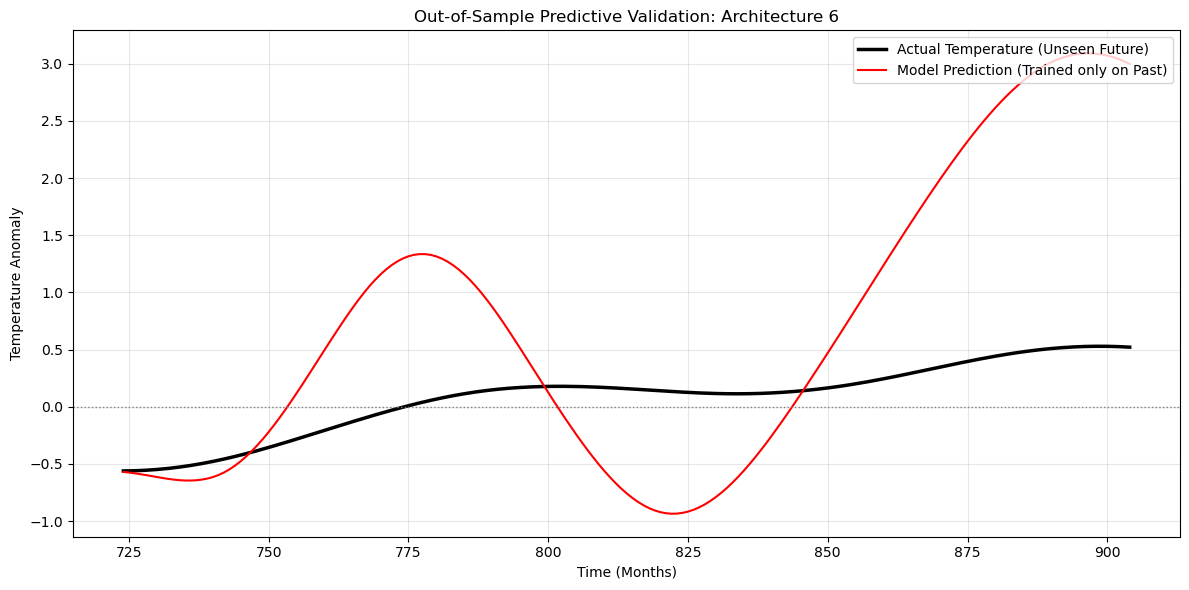

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from pygam import LinearGAM, te, l
from sklearn.metrics import r2_score, mean_squared_error

# ==============================================================================
# 1. TIME-SERIES CHRONOLOGICAL SPLIT (80% Train / 20% Test)
# ==============================================================================
# We CANNOT use random cross-validation on time series due to autocorrelation.
# We must split chronologically.

split_index = int(len(X_concurrent) * 0.80)

# Training Data (The Past: e.g., 1950 to ~2010)
X_train = X_concurrent[:split_index]
y_train = y_concurrent[:split_index]

# Testing Data (The Future: e.g., ~2010 to 2025)
X_test = X_concurrent[split_index:]
y_test = y_concurrent[split_index:]

print(f"Training Observations: {len(X_train)}")
print(f"Testing Observations:  {len(X_test)}")

# ==============================================================================
# 2. ISOLATED TRAINING
# ==============================================================================
# Fit Architecture 6 STRICTLY on the training subset
validation_model = LinearGAM(te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + l(3) + s(4, spline_order=2))
validation_model.gridsearch(X_train, y_train, progress=False)

# ==============================================================================
# 3. BLIND PREDICTION & METRICS
# ==============================================================================
# Force the model to predict the test set (which it has never seen)
y_pred_test = validation_model.predict(X_test)

# Calculate Out-of-Sample R-Squared and MSE
# Using sklearn's r2_score for standard out-of-sample evaluation
out_of_sample_r2 = r2_score(y_test, y_pred_test)
out_of_sample_mse = mean_squared_error(y_test, y_pred_test)

print(f"\n--- OUT-OF-SAMPLE DIAGNOSTICS ---")
print(f"Out-of-Sample R-Squared: {out_of_sample_r2:.4f}")
print(f"Out-of-Sample MSE:       {out_of_sample_mse:.4f}")

# ==============================================================================
# 4. VISUAL VALIDATION
# ==============================================================================
plt.figure(figsize=(12, 6))

# Create a continuous time axis for plotting
time_test = np.arange(split_index, len(y_concurrent))

plt.plot(time_test, y_test, color='black', linewidth=2.5, label='Actual Temperature (Unseen Future)')
plt.plot(time_test, y_pred_test, color='red', linewidth=1.5, label='Model Prediction (Trained only on Past)')

plt.title('Out-of-Sample Predictive Validation: Architecture 6')
plt.xlabel('Time (Months)')
plt.ylabel('Temperature Anomaly')
plt.axhline(0, color='gray', linestyle=':', linewidth=1)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [101]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd
from pygam import LinearGAM

# Define the number of folds (5 folds for decadal data)
tscv = TimeSeriesSplit(n_splits=5)

fold_metrics = []

# CORRECT UNPACKING: Separate the string name from the PyGAM formulation
for name, formulation in architectures.items():
    print(f"Testing Architecture: {name}...")
    
    for fold, (train_index, test_index) in enumerate(tscv.split(X_final), 1):
        # Split the data chronologically
        X_train, X_test = X_final[train_index], X_final[test_index]
        y_train, y_test = y_final[train_index], y_final[test_index]

        # Instantiate the model with the isolated TermList
        model = LinearGAM(formulation)
        
        try:
            # Fit and Predict
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            # Calculate Metrics
            r2 = r2_score(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)
            
            fold_metrics.append({
                'Architecture': name,
                'Fold': fold,
                'R2': r2,
                'MSE': mse
            })
        except Exception as e:
            # PyGAM splines can occasionally fail to fit on the very first 
            # fold if the training sample is too small. We catch that here.
            fold_metrics.append({
                'Architecture': name,
                'Fold': fold,
                'R2': np.nan,
                'MSE': np.nan
            })

# Compile the raw fold data
df_folds = pd.DataFrame(fold_metrics)

# Calculate the mean Out-of-Sample R2 across all 5 folds to find the definitive winner
df_summary = df_folds.groupby('Architecture')['R2'].mean().sort_values(ascending=False).reset_index()

print("\n===========================================================")
print("CROSS-VALIDATED OUT-OF-SAMPLE STABILITY RANKING (5 FOLDS)")
print("===========================================================")
print(df_summary.to_string(index=False))

Testing Architecture: 1. Strictly Linear (Additive)...
Testing Architecture: 2. Independent Splines (Non-Linear Additive)...
Testing Architecture: 3. Interaction: [NAO x EA] + Splines(SCA, AMO)...
Testing Architecture: 4. Interaction: [NAO x SCA] + Splines(EA, AMO)...
Testing Architecture: 5. Interaction: [EA x SCA] + Splines(NAO, AMO)...
Testing Architecture: 6. 3-Way Atmospheric Tensor + Linear AMO...
Testing Architecture: 7. 3-Way Atmospheric Tensor + Spline AMO...
Testing Architecture: 8. Full 4-Way Tensor (Atmosphere x Ocean)...

CROSS-VALIDATED OUT-OF-SAMPLE STABILITY RANKING (5 FOLDS)
                                  Architecture           R2
                 1. Strictly Linear (Additive)   -73.905687
4. Interaction: [NAO x SCA] + Splines(EA, AMO)  -517.951555
5. Interaction: [EA x SCA] + Splines(NAO, AMO)  -535.942926
      6. 3-Way Atmospheric Tensor + Linear AMO  -750.596363
  2. Independent Splines (Non-Linear Additive)  -919.530952
3. Interaction: [NAO x EA] + Splines(SCA,

Historical Epoch R-Squared: 0.7185


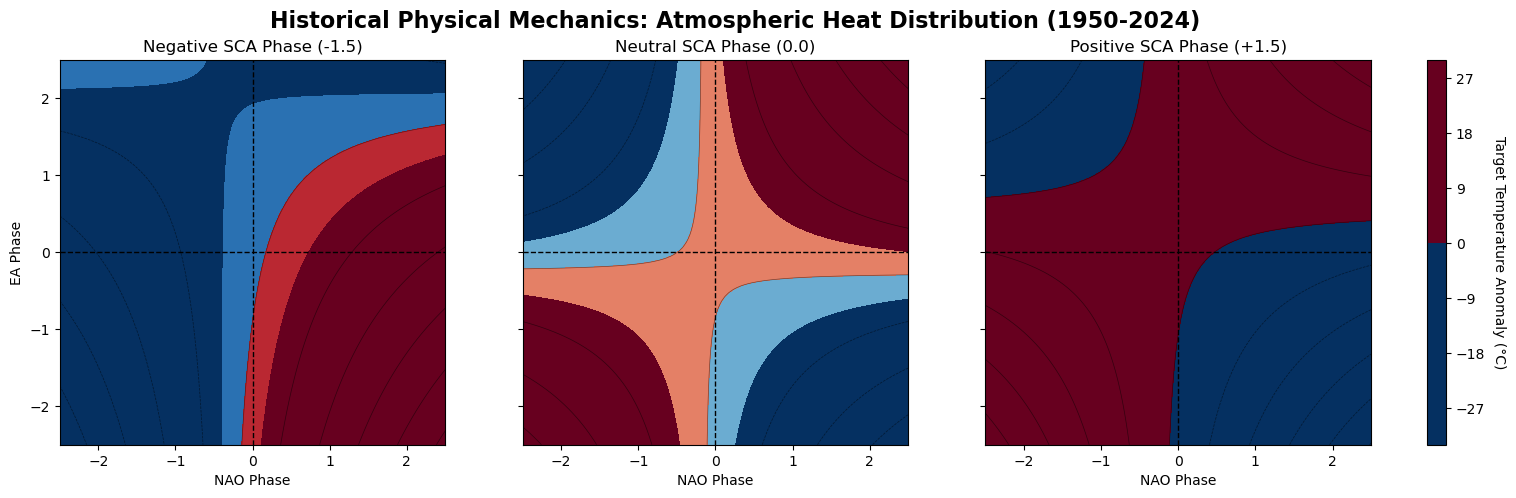

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, te, l, s

# ==============================================================================
# 1. FIT THE EPOCHAL MODEL (1950 - 2024)
# ==============================================================================
# We use the full matrix to map the complete historical epoch.
# Index 0: NAO, 1: EA, 2: SCA, 3: AMO_Lagged, 4: Background_Trend
model = LinearGAM(
    te(0, 1, 2, n_splines=(4, 4, 4)) + l(3) + s(4, spline_order=2)
)
model.fit(X_final, y_final)

print(f"Historical Epoch R-Squared: {model.statistics_['pseudo_r2']['explained_deviance']:.4f}")

# ==============================================================================
# 2. SYNTHESIZE THE PHASE SPACE
# ==============================================================================
# To visualize a 3D interaction (NAO x EA x SCA), we must look at 2D slices.
# We will create a grid of NAO and EA combinations, and view them under 
# three different "regimes" of the Scandinavian Blocking pattern (SCA).

# Define the grid boundaries (typically -2.5 to +2.5 standard deviations)
nao_range = np.linspace(-2.5, 2.5, 100)
ea_range = np.linspace(-2.5, 2.5, 100)

# Create the 2D meshgrid
NAO_grid, EA_grid = np.meshgrid(nao_range, ea_range)

# Flatten the grids for PyGAM prediction
NAO_flat = NAO_grid.flatten()
EA_flat = EA_grid.flatten()

# Freeze the slow-moving baselines at zero (neutral ocean, neutral trend)
# This isolates the pure atmospheric physics.
AMO_neutral = np.zeros_like(NAO_flat)
Trend_neutral = np.zeros_like(NAO_flat)

# Define the three SCA phases to test
sca_phases = {
    "Negative SCA Phase (-1.5)": -1.5,
    "Neutral SCA Phase (0.0)": 0.0,
    "Positive SCA Phase (+1.5)": 1.5
}

# ==============================================================================
# 3. VISUALIZE THE THERMODYNAMIC MECHANICS
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Historical Physical Mechanics: Atmospheric Heat Distribution (1950-2024)', fontsize=16, fontweight='bold')

for ax, (title, sca_val) in zip(axes, sca_phases.items()):
    
    # Create the SCA array for this specific slice
    SCA_flat = np.full_like(NAO_flat, sca_val)
    
    # Assemble the synthetic feature matrix
    X_synthetic = np.column_stack((NAO_flat, EA_flat, SCA_flat, AMO_neutral, Trend_neutral))
    
    # Predict the thermal anomaly for this specific grid
    Temp_pred = model.predict(X_synthetic)
    
    # Reshape back to 2D for contour plotting
    Temp_grid = Temp_pred.reshape(100, 100)
    
    # Plot the heat map (Contour)
    contour = ax.contourf(NAO_grid, EA_grid, Temp_grid, levels=20, cmap='RdBu_r', vmin=-1.0, vmax=1.0)
    ax.contour(NAO_grid, EA_grid, Temp_grid, levels=10, colors='black', linewidths=0.5, alpha=0.5)
    
    ax.set_title(title)
    ax.set_xlabel('NAO Phase')
    if ax == axes[0]:
        ax.set_ylabel('EA Phase')
    
    # Add crosshairs for the neutral (0,0) center
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)

# Add a shared colorbar
cbar = fig.colorbar(contour, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04)
cbar.set_label('Target Temperature Anomaly (°C)', rotation=270, labelpad=15)

plt.show()

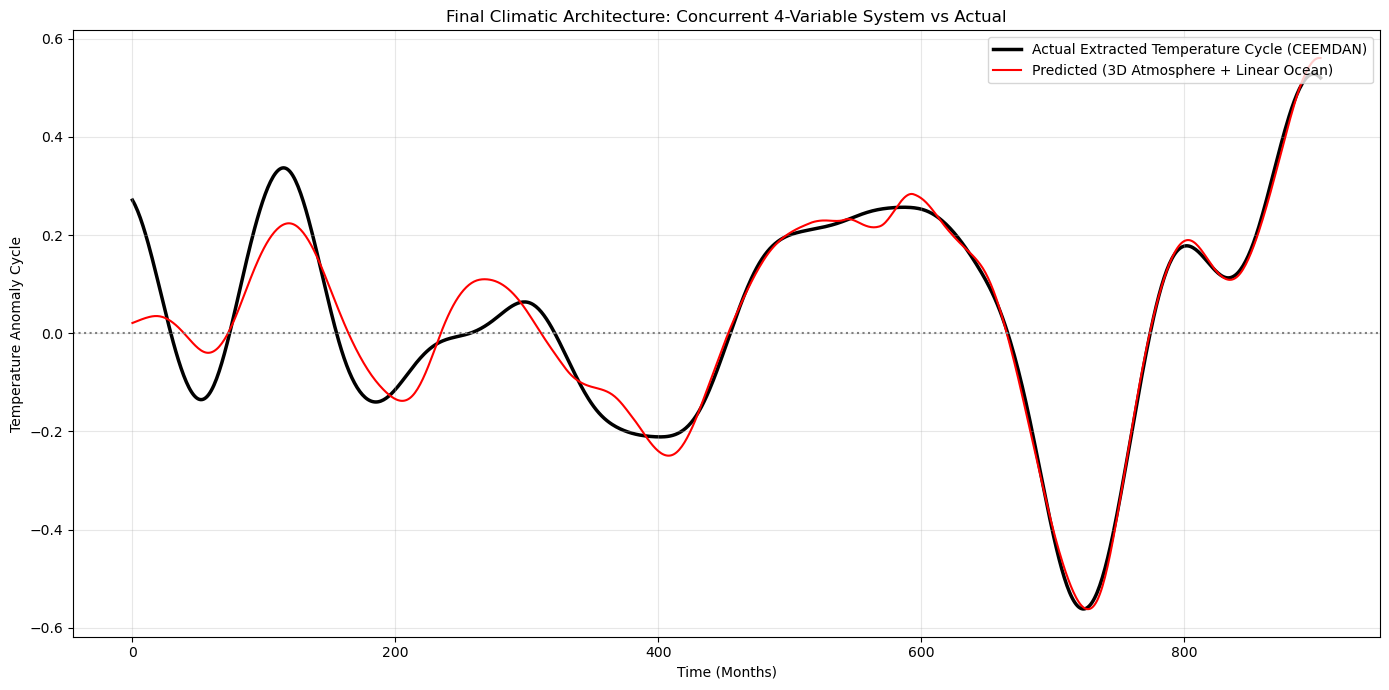

Final Model Mean Squared Error: 0.0024


In [102]:
import matplotlib.pyplot as plt

# Instantiate and fit the optimal architecture
# Index 0: NAO, Index 1: EA, Index 2: SCA, Index 3: AMO
final_concurrent_model = LinearGAM(te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + l(3) + s(4, spline_order=2))
final_concurrent_model.fit(X_concurrent, y_concurrent)

# Generate predictions
y_pred_final = final_concurrent_model.predict(X_concurrent)

# Plot the Final Verification
plt.figure(figsize=(14, 7))

plt.plot(y_concurrent, color='black', linewidth=2.5, label='Actual Extracted Temperature Cycle (CEEMDAN)', zorder=1)
plt.plot(y_pred_final, color='red', linewidth=1.5, label='Predicted (3D Atmosphere + Linear Ocean)', zorder=2)

plt.title('Final Climatic Architecture: Concurrent 4-Variable System vs Actual')
plt.xlabel('Time (Months)')
plt.ylabel('Temperature Anomaly Cycle')
plt.axhline(0, color='gray', linestyle=':', linewidth=1.5)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Final Error Metric
mse_final = np.nanmean((y_concurrent - y_pred_final)**2)
print(f"Final Model Mean Squared Error: {mse_final:.4f}")

In [120]:
df_gam_filtered= df_gam_filtered.drop(columns="test")

In [108]:
df_gam_filtered['AMO_Cycle']

Date
1950-01-01   -0.03
1950-02-01   -0.13
1950-03-01   -0.16
1950-04-01   -0.22
1950-05-01   -0.23
              ... 
2025-01-01    0.98
2025-02-01    0.86
2025-03-01    0.75
2025-04-01    0.67
2025-05-01    0.73
Name: AMO_Cycle, Length: 905, dtype: float64

In [96]:
df_amo[2]

0     -0.03
1     -0.13
2     -0.16
3     -0.22
4     -0.23
       ... 
907    0.83
908    0.76
909    1.01
910    0.96
911    0.75
Name: 2, Length: 912, dtype: float64

In [21]:
from pygam import LinearGAM, te, l, s

# We force a low-resolution tensor grid. 
# n_splines=(5, 5, 5) limits the basis functions for each dimension.
architectures_constrained = {
    # The unrestricted winner (for direct baseline comparison)
    "Unrestricted 3-Way Tensor": te(0, 1, 2),
    
    # Constrained 3-Way Tensors
    "Constrained 3-Way (5 nodes)": te(0, 1, 2, n_splines=(5, 5, 5)),
    "Constrained 3-Way (4 nodes)": te(0, 1, 2, n_splines=(4, 4, 4)),
    
    # Constrained 2-Way Tensors with Linear Baseline
    "Constrained 2-Way (NAO & EA) + Linear Lag": te(0, 2, n_splines=(6, 6)) + l(1),
    
    # The purely linear baseline (to ensure the restricted tensors still outperform it)
    "Linear Baseline": l(0) + l(1) + l(2)
}

results_constrained = []

for name, formulation in architectures_constrained.items():
    model = LinearGAM(formulation)
    model.gridsearch(X, y, progress=False)
    
    results_constrained.append({
        "Architecture": name,
        "AIC": model.statistics_['AIC'],
        "GCV": model.statistics_['GCV'],
        "EDOF": model.statistics_['edof'],
        "Pseudo R-Squared": model.statistics_['pseudo_r2']['explained_deviance']
    })

df_constrained = pd.DataFrame(results_constrained).sort_values(by="AIC")
print(df_constrained.to_string(index=False))

                             Architecture        AIC      GCV       EDOF  Pseudo R-Squared
                Unrestricted 3-Way Tensor 332.267466 0.104665 114.786017          0.612492
              Constrained 3-Way (5 nodes) 592.798317 0.129320  29.064896          0.316594
              Constrained 3-Way (4 nodes) 647.036489 0.136445  14.894419          0.239557
Constrained 2-Way (NAO & EA) + Linear Lag 647.414753 0.137710  22.669170          0.254446
                          Linear Baseline 725.709803 0.149218   3.960025          0.134358


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Instantiate and fit the winning architecture
# Index 0: NAO, Index 1: NAO_Lag135, Index 2: EA
final_gam = LinearGAM(te(0, 2) + l(1))
final_gam.gridsearch(X, y, progress=False)

# Generate a 2D grid for the tensor term (term=0 corresponds to te(0, 2))
# This creates a meshgrid of the NAO (feature 0) and EA (feature 2)
XX = final_gam.generate_X_grid(term=0, n=100)

# Calculate the partial dependence (the isolated temperature impact)
Z = final_gam.partial_dependence(term=0, X=XX)

# Reshape the output for contour plotting
x_nao = XX[:, 0].reshape(100, 100)
y_ea = XX[:, 2].reshape(100, 100)
z_temp = Z.reshape(100, 100)

# Plot the Interaction Surface
plt.figure(figsize=(10, 8))
contour = plt.contourf(x_nao, y_ea, z_temp, levels=50, cmap='coolwarm')
plt.colorbar(contour, label='Partial Dependence: Target Temperature Impact')

# Formatting
plt.title('NAO & EA Coupled Interaction Manifold')
plt.xlabel('North Atlantic Oscillation (NAO) Z-Score')
plt.ylabel('East Atlantic Pattern (EA) Z-Score')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

# Output the coefficient for the strictly linear 135-month gyre lag (term 1)
gyre_coef = final_gam.coef_[-2] # Second to last coefficient is the linear term, last is intercept
print(f"Linear Gyre Forcing Coefficient (Lag 135): {gyre_coef:.5f}")

ValueError: term requires feature 2, but X has only 2 dimensions

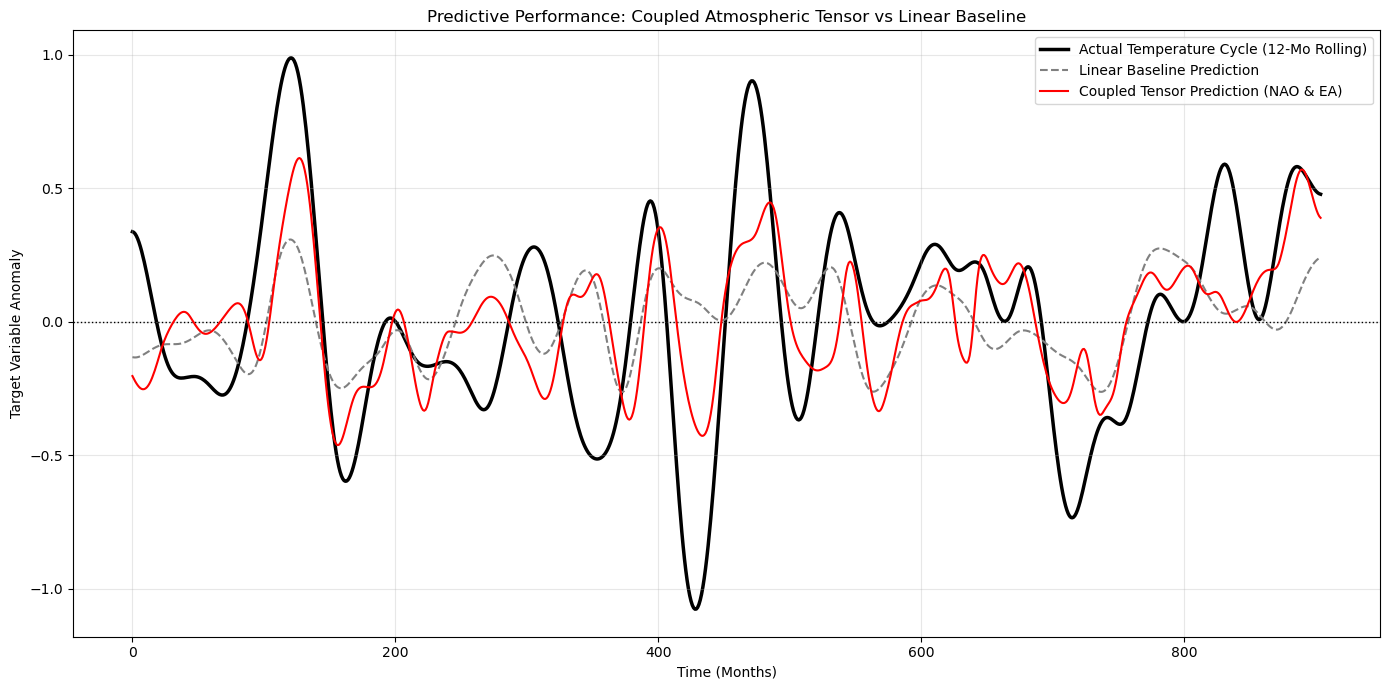

MSE (Linear Baseline vs Cycle): 0.1290
MSE (Tensor Model vs Cycle):    0.0903


In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, l, te

# ==============================================================================
# 1. MODEL INSTANTIATION AND PREDICTION
# ==============================================================================
# Ensure your feature matrix X (NAO, NAO_Lag135, EA) and target y are loaded.
# Re-instantiate and fit the two competing models
X= X_final
y= y_final
model_linear = LinearGAM(l(0) + l(1) + l(2))
model_linear.fit(X, y)

model_tensor = LinearGAM(te(0, 1, 2, n_splines=(3, 3, 3), spline_order=2) + te(3, 4, n_splines=(4, 4), spline_order=2))
model_tensor.fit(X, y)

# Generate the predicted arrays
y_pred_linear = model_linear.predict(X)
y_pred_tensor = model_tensor.predict(X)

# ==============================================================================
# 2. ISOLATING THE TARGET CYCLE
# ==============================================================================
# To plot "against the cycles", we calculate a 12-month moving average of the 
# actual temperature to filter out high-frequency noise and reveal the base cycle.
# (Alternatively, you can replace 'y_cycle' directly with your CEEMDAN IMF 5 array)
y_series = pd.Series(y)
y_cycle = y

# ==============================================================================
# 3. PLOTTING THE COMPARISON
# ==============================================================================
# Create a time array (assuming monthly data, length matches y)
time_axis = np.arange(len(y))

plt.figure(figsize=(14, 7))

# Plot 1: The underlying physical cycle (Smoothed Actuals or IMF)
plt.plot(time_axis, y_cycle, color='black', linewidth=2.5, label='Actual Temperature Cycle (12-Mo Rolling)', zorder=1)

# Plot 2: The Linear Baseline Prediction
plt.plot(time_axis, y_pred_linear, color='gray', linestyle='--', linewidth=1.5, label='Linear Baseline Prediction', zorder=2)

# Plot 3: The Tensor Interaction Prediction
plt.plot(time_axis, y_pred_tensor, color='red', linewidth=1.5, label='Coupled Tensor Prediction (NAO & EA)', zorder=3)

# Formatting the plot
plt.title('Predictive Performance: Coupled Atmospheric Tensor vs Linear Baseline')
plt.xlabel('Time (Months)')
plt.ylabel('Target Variable Anomaly')
plt.axhline(0, color='black', linestyle=':', linewidth=1)

# Optional: Zoom in on a specific 20-year window to see the exact divergence
# plt.xlim(200, 440) 

plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================================================================
# 4. RESIDUAL CALCULATION (Optional Diagnostic)
# ==============================================================================
# Calculate the Mean Squared Error against the cycle to quantify the visual gap
mse_linear = np.nanmean((y_cycle - y_pred_linear)**2)
mse_tensor = np.nanmean((y_cycle - y_pred_tensor)**2)

print(f"MSE (Linear Baseline vs Cycle): {mse_linear:.4f}")
print(f"MSE (Tensor Model vs Cycle):    {mse_tensor:.4f}")